# Predicción de Default en Préstamos de Lending Club

## Machine Learning

### Estudiante
Leonella Torreglosa

### Objetivo

Construir modelos de clasificación supervisada para predecir si un préstamo terminará en default (Charged Off) o será pagado completamente (Fully Paid).

Se realizará:

- Exploración de Datos (EDA)
- Preprocesamiento
- Entrenamiento de modelos
- Evaluación mediante métricas de clasificación
- Comparación de resultados

In [5]:
# IMPORTACIÓN DE LIBERIAS
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Configuración visual
plt.style.use("ggplot")

In [2]:
# Ocultar warnings para mejorar la legibilidad del notebook

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

# Exploración de datos (EDA)

## 1. Carga inicial y visión general

Nombre: Lending Club Loan Data (2007–2020)

Fuente: Kaggle Dataset - Lending Club

Tamaño: más de 1,3 millones de registros

Características: variables socioeconómicas, financieras, de crédito, empleo y propósito del préstamo

Condición obligatoria: Se debe utilizar el dataset completo sin ningún tipo de muestreo, submuestreo o reducción de filas. No se permite trabajar con versiones reducidas del conjunto de datos.

In [6]:
# Ruta completa del dataset

ruta = r"C:\Users\Leonella Torreglosa\OneDrive\Escritorio\MachineLearningUN\LendingClub_Proyecto_Data\accepted_2007_to_2018Q4.csv.gz"

# Cargar dataset

df = pd.read_csv(
    ruta,
    compression="gzip",
    low_memory=False
)

print("Dataset cargado correctamente")

Dataset cargado correctamente


In [4]:
# Número de filas y columnas del dataset

print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(2260701, 151)


In [5]:
# Mostrar las primeras observaciones

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Mostrar las últimas observaciones

df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Tipos de datos y valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [8]:
# Resumen estadístico de variables numéricas

df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


#### Dimensiones del Dataset

Se reporta el número total de filas y columnas presentes en el conjunto de datos.

In [9]:
# Obtener el número de filas y columnas

filas, columnas = df.shape

print(f"Número de filas: {filas:,}")
print(f"Número de columnas: {columnas}")

Número de filas: 2,260,701
Número de columnas: 151


#### Interpretación

El dataset contiene aproximadamente 2.260.701 registros y 151 variables.

Esto confirma que se trata de un conjunto de datos de gran tamaño, adecuado para comparar el rendimiento de herramientas de procesamiento como scikit-learn y PySpark.

## 2. Creación de la variable objetivo (default)

La variable loan_status será transformada en una variable binaria:

- 0 = Fully Paid
- 1 = Charged Off

In [8]:
# Conservar únicamente préstamos Fully Paid y Charged Off

df = df[
    df["loan_status"].isin(
        ["Fully Paid", "Charged Off"]
    )
].copy()

# Crear variable objetivo "default" a partir de la variable "loan_status"
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)
df[["loan_status","default"]].head()

,loan_status,default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0


#### Verificación de categorías de la variable objetivo

In [10]:
# Verificar categorías restantes de loan_status

df["loan_status"].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

Tras el filtrado, únicamente se conservaron las categorías Fully Paid y Charged Off, tal como lo requiere el enunciado para la construcción de la variable objetivo.

### 2.1 Análisis unidimensional de variables numéricas

Se analizarán las siguientes variables numéricas representativas:

- loan_amnt
- int_rate
- annual_inc
- dti
- fico_range_high

Para cada variable se calcularán medidas descriptivas, detección de valores atípicos, visualizaciones y análisis de valores faltantes.

In [12]:
# Variables numéricas seleccionadas

numericas = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high"
]

#### Estadísticos descriptivos

In [13]:
# Tabla de estadísticas descriptivas

estadisticas = pd.DataFrame()

for col in numericas:

    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)

    estadisticas.loc[col, "Media"] = df[col].mean()
    estadisticas.loc[col, "Mediana"] = df[col].median()
    estadisticas.loc[col, "Desv. Est."] = df[col].std()

    estadisticas.loc[col, "Min"] = df[col].min()
    estadisticas.loc[col, "Q1"] = q1
    estadisticas.loc[col, "Q2"] = q2
    estadisticas.loc[col, "Q3"] = q3
    estadisticas.loc[col, "Max"] = df[col].max()

    # Rango intercuartílico
    estadisticas.loc[col, "IQR"] = q3 - q1

# Mostrar tabla redondeada a 2 decimales
estadisticas.round(2)

,Media,Mediana,Desv. Est.,Min,Q1,Q2,Q3,Max,IQR
loan_amnt,14419.97,12000.00,8717.05,500.00,8000.00,12000.00,20000.00,40000.00,12000.00
int_rate,13.24,12.74,4.77,5.31,9.75,12.74,15.99,30.99,6.24
annual_inc,76247.64,65000.00,69925.10,0.00,45780.00,65000.00,90000.00,10999200.00,44220.00
dti,18.28,17.61,11.16,-1.00,11.79,17.61,24.06,999.00,12.27
fico_range_high,700.19,694.00,31.85,629.00,674.00,694.00,714.00,850.00,40.00


#### Interpretación

La tabla presenta las principales medidas descriptivas de las variables numéricas seleccionadas.

- La media y la mediana permiten evaluar la tendencia central de cada variable. Cuando existen diferencias importantes entre ambas medidas, puede existir asimetría en la distribución.

- La desviación estándar muestra la dispersión de los datos respecto a la media. Valores elevados indican una mayor variabilidad.

- Los percentiles Q1 (25 %), Q2 (50 %) y Q3 (75 %) permiten analizar la distribución de los datos y calcular el rango intercuartílico (IQR), utilizado posteriormente para detectar valores atípicos.

- Las diferencias observadas entre los valores mínimos y máximos sugieren la posible presencia de outliers en algunas variables financieras como annual_inc y loan_amnt.

### Interpretación de las estadísticas descriptivas

Las variables analizadas presentan características diferentes en términos de dispersión, rango y distribución.

- El monto del préstamo (`loan_amnt`) presenta una media de aproximadamente 14.420 dólares y una mediana de 12.000 dólares. Como la media es superior a la mediana, existe evidencia de una distribución sesgada a la derecha debido a préstamos de alto valor.

- La tasa de interés (`int_rate`) muestra una media de 13,24 % y una mediana de 12,74 %, con una dispersión moderada. Esto indica que la mayoría de los préstamos poseen tasas relativamente cercanas a dichos valores.

- El ingreso anual (`annual_inc`) presenta una diferencia considerable entre la media (76.247 dólares) y la mediana (65.000 dólares), además de una desviación estándar muy elevada. Esto sugiere la presencia de ingresos extremadamente altos que incrementan artificialmente la media.

- La variable `dti` (debt-to-income ratio) muestra una media de 18,28 y una mediana de 17,61, indicando una distribución relativamente concentrada aunque con posibles valores extremos.

- La puntuación FICO superior (`fico_range_high`) presenta menor variabilidad en comparación con las demás variables, con valores concentrados entre 674 y 714 puntos para el 50 % central de las observaciones.

En general, las diferencias entre media y mediana observadas en variables como `loan_amnt` y `annual_inc` sugieren asimetrías y posibles valores atípicos, los cuales serán analizados mediante el método del rango intercuartílico (IQR) en la siguiente sección.

### Identificación de valores atípicos (Outliers)

Se utiliza el método del rango intercuartílico (IQR) para detectar observaciones extremas.

Una observación se considera outlier cuando:

- x < Q1 − 1.5 × IQR
- x > Q3 + 1.5 × IQR

In [14]:
# Detección de outliers mediante IQR

for col in numericas:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ].shape[0]

    print(f"{col}: {cantidad_outliers:,} outliers")

loan_amnt: 7,157 outliers
int_rate: 24,977 outliers
annual_inc: 65,870 outliers
dti: 5,473 outliers
fico_range_high: 46,497 outliers


### Histogramas de distribución

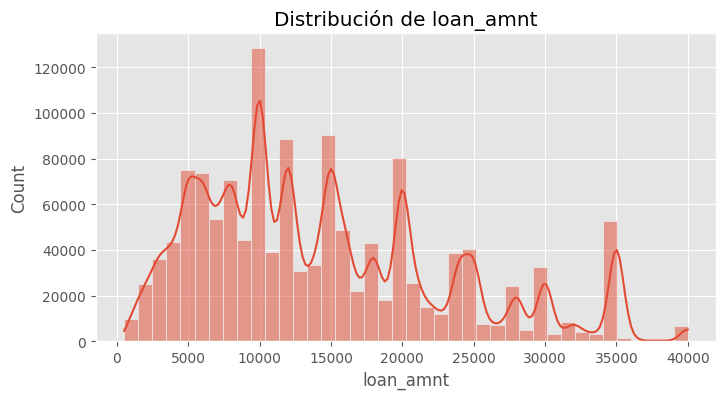

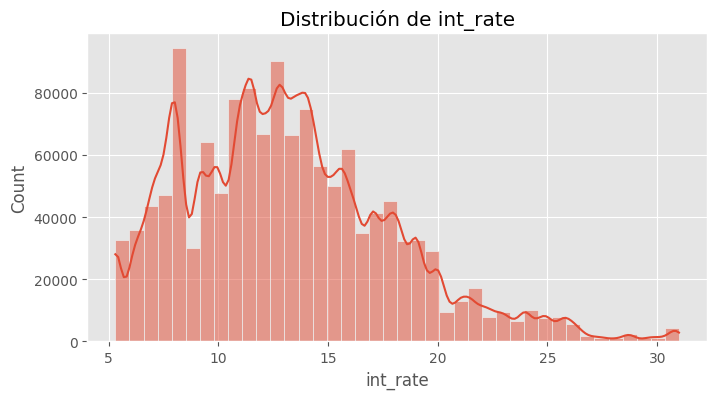

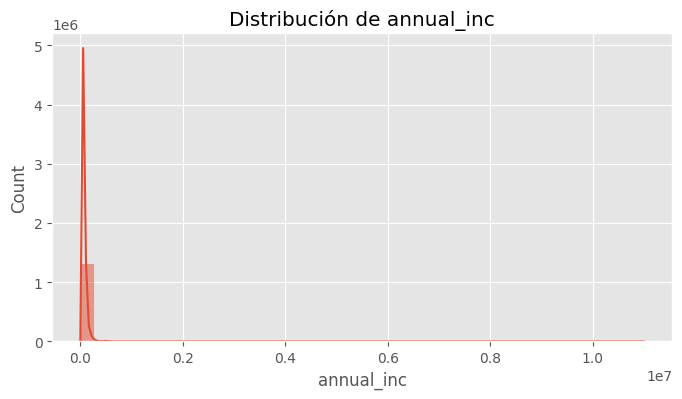

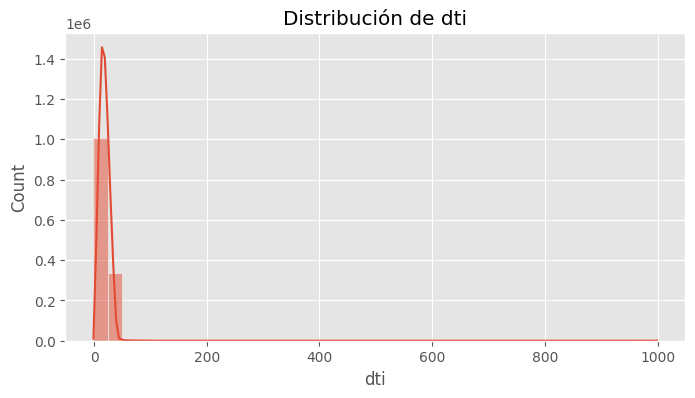

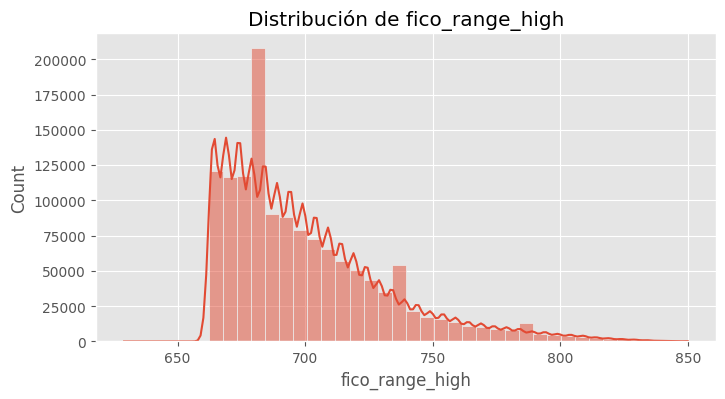

In [15]:
for col in numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        bins=40,
        kde=True
    )

    plt.title(f"Distribución de {col}")

    plt.show()

### Diagramas de Caja (Boxplots)

Los diagramas de caja permiten identificar la mediana, la dispersión de los datos y la posible presencia de valores atípicos (outliers).

Además, ayudan a detectar asimetrías en la distribución de las variables numéricas.

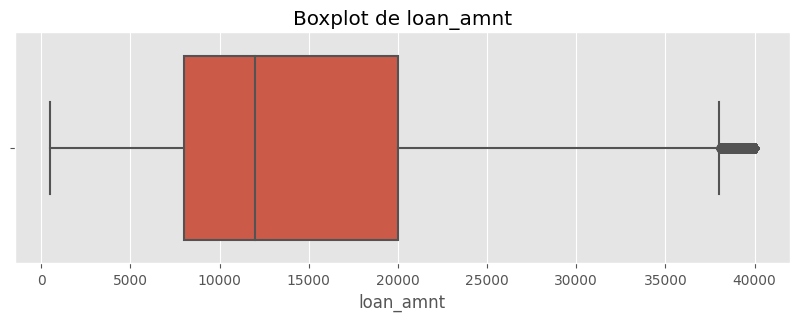

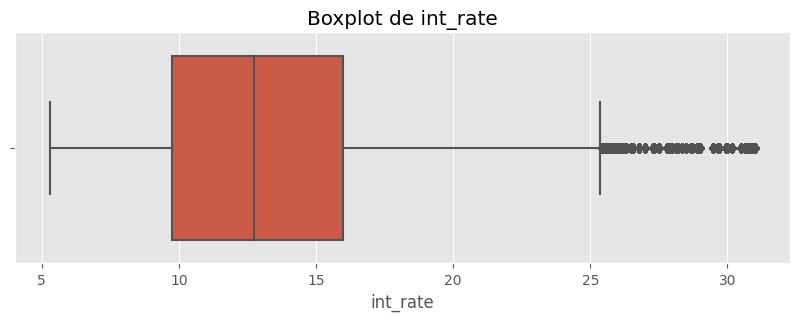

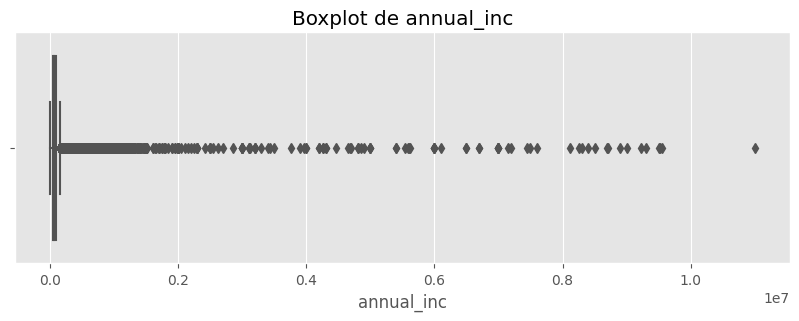

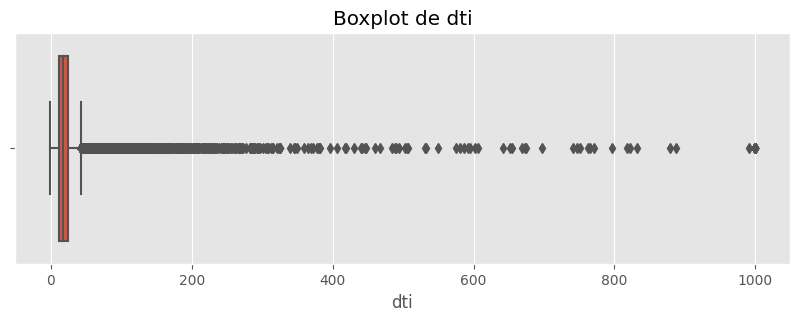

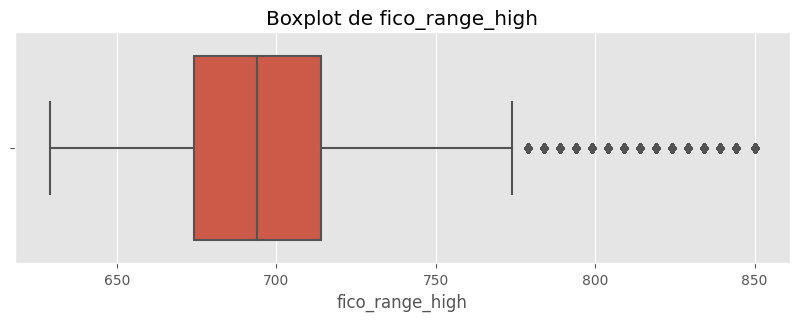

In [16]:
# Generar boxplots para las variables numéricas

for col in numericas:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot de {col}")

    plt.xlabel(col)

    plt.show()

### Interpretación de los diagramas de caja

Los diagramas de caja permiten identificar la dispersión de los datos y la presencia de valores atípicos en las variables numéricas analizadas.

- La variable `annual_inc` presenta una fuerte asimetría positiva y una gran cantidad de valores extremos. La mayoría de las observaciones se concentra en niveles de ingreso relativamente bajos, mientras que algunos prestatarios reportan ingresos excepcionalmente altos.

- La variable `dti` también muestra numerosos valores atípicos, con observaciones muy alejadas del rango central de la distribución.

- En `loan_amnt`, aunque la mayor parte de los préstamos se concentra entre aproximadamente 8.000 y 20.000 dólares, se observan valores extremos cercanos al límite superior del monto permitido.

- La variable `int_rate` presenta menor dispersión que las variables anteriores, aunque existen algunas observaciones con tasas considerablemente superiores al rango central.

- La variable `fico_range_high` muestra una distribución más compacta y estable, aunque aún se observan algunos valores atípicos en la parte superior de la escala FICO.

En general, la presencia de outliers es consistente con la naturaleza financiera del conjunto de datos y deberá considerarse durante las etapas posteriores de preprocesamiento y modelado.

### Identificación de valores atípicos mediante el método IQR

Se consideran valores atípicos aquellas observaciones que se encuentran fuera del intervalo:

[Q1 - 1.5 × IQR, Q3 + 1.5 × IQR]

donde IQR corresponde al rango intercuartílico.

In [17]:
# Detección de outliers usando IQR

for col in numericas:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    print(f"{col}: {len(outliers):,} valores atípicos")

loan_amnt: 7,157 valores atípicos
int_rate: 24,977 valores atípicos
annual_inc: 65,870 valores atípicos
dti: 5,473 valores atípicos
fico_range_high: 46,497 valores atípicos


### Evaluación de la normalidad mediante asimetría

La asimetría (skewness) permite evaluar si una distribución se aproxima a una distribución normal.

- Asimetría cercana a 0: distribución aproximadamente simétrica.
- Asimetría positiva: cola hacia la derecha.
- Asimetría negativa: cola hacia la izquierda.


In [18]:
# Calcular asimetría

for col in numericas:

    skewness = df[col].skew()

    print(f"{col}: {skewness:.4f}")

loan_amnt: 0.7825
int_rate: 0.7135
annual_inc: 46.3179
dti: 27.1106
fico_range_high: 1.2857


### Interpretación de la asimetría

Los coeficientes de asimetría muestran que ninguna de las variables analizadas sigue una distribución normal perfecta.

- `loan_amnt` presenta una asimetría positiva moderada (0.78), indicando una mayor concentración de préstamos de montos bajos y medios, con algunos préstamos de alto valor.

- `int_rate` presenta una asimetría positiva moderada (0.71), lo que sugiere una ligera concentración de préstamos con tasas de interés inferiores al promedio.

- `annual_inc` presenta una asimetría extremadamente alta (46.32), evidenciando la existencia de ingresos excepcionalmente elevados que generan una cola muy larga hacia la derecha.

- `dti` presenta una asimetría muy alta (27.11), indicando la presencia de valores extremos en la relación deuda-ingreso.

- `fico_range_high` muestra una asimetría positiva moderada (1.29), con algunos prestatarios que poseen puntuaciones crediticias considerablemente superiores al promedio.

Los resultados confirman lo observado en los histogramas y diagramas de caja: existen valores atípicos importantes, especialmente en las variables `annual_inc` y `dti`. Por lo tanto, durante el preprocesamiento podría evaluarse el uso de transformaciones como logaritmo o técnicas robustas al sesgo y a los valores extremos.

### Necesidad de transformaciones

Los resultados de asimetría indican que varias variables presentan distribuciones alejadas de la normalidad.

Las variables `annual_inc` (46.32) y `dti` (27.11) muestran una asimetría positiva extremadamente elevada, lo que evidencia la existencia de valores extremos y colas largas hacia la derecha. En estos casos, podría evaluarse el uso de transformaciones logarítmicas para reducir la asimetría y mejorar la estabilidad de algunos modelos sensibles a la escala y distribución de las variables.

Por otro lado, `loan_amnt` (0.78) e `int_rate` (0.71) presentan una asimetría moderada, por lo que inicialmente podrían mantenerse sin transformación y evaluar posteriormente su impacto en el desempeño de los modelos.

La variable `fico_range_high` presenta una asimetría positiva moderada (1.29), por lo que también podría considerarse una transformación si se observa un beneficio durante el proceso de modelado.

La transformación Box-Cox requiere valores estrictamente positivos y suele utilizarse cuando se desea aproximar una distribución normal. Sin embargo, dado el gran tamaño del dataset y la presencia de algoritmos basados en árboles (Decision Tree, Random Forest y GBT), que son robustos frente a distribuciones no normales, la necesidad de aplicar estas transformaciones deberá evaluarse empíricamente durante el modelado.


### Tasa de valores faltantes por variable

Se calcula el porcentaje de valores faltantes para cada una de las variables numéricas seleccionadas.

Posteriormente se definirá un umbral del 30 % para decidir si una variable requiere imputación o una evaluación más profunda para su posible exclusión.

In [19]:
# Calcular porcentaje de valores faltantes

missing_numeric = pd.DataFrame({
    "Variable": numericas,
    "Valores_Faltantes": [
        df[col].isnull().sum()
        for col in numericas
    ],
    "Porcentaje_Faltantes": [
        (df[col].isnull().mean()) * 100
        for col in numericas
    ]
})

missing_numeric.round(2)

,Variable,Valores_Faltantes,Porcentaje_Faltantes
0,loan_amnt,0,0.00
1,int_rate,0,0.00
2,annual_inc,0,0.00
3,dti,374,0.03
4,fico_range_high,0,0.00


In [20]:
# Ordenar de mayor a menor porcentaje de faltantes

missing_numeric = missing_numeric.sort_values(
    by="Porcentaje_Faltantes",
    ascending=False
)

missing_numeric.round(2)

,Variable,Valores_Faltantes,Porcentaje_Faltantes
3,dti,374,0.03
0,loan_amnt,0,0.00
1,int_rate,0,0.00
2,annual_inc,0,0.00
4,fico_range_high,0,0.00


### Interpretación de los valores faltantes

Las variables numéricas analizadas presentan una excelente calidad de datos en términos de completitud.

La única variable con valores faltantes es `dti`, con aproximadamente un 0,03 % de observaciones ausentes, porcentaje que resulta insignificante considerando el tamaño total del conjunto de datos.

Las variables `loan_amnt`, `int_rate`, `annual_inc` y `fico_range_high` no presentan valores faltantes.

Como criterio de decisión se establece un umbral del 30 % de datos faltantes para evaluar posibles eliminaciones o tratamientos avanzados. Ninguna de las variables seleccionadas supera dicho umbral, por lo que podrán mantenerse para el modelado posterior. En el caso de `dti`, una imputación sencilla mediante mediana sería suficiente dada la baja proporción de valores ausentes.

### Conclusión del análisis unidimensional de variables numéricas

Las variables numéricas presentan distribuciones heterogéneas y, en algunos casos, una marcada asimetría positiva.

Los histogramas, diagramas de caja y coeficientes de asimetría evidencian la presencia de valores atípicos, especialmente en `annual_inc` y `dti`. Sin embargo, la calidad de los datos es alta debido al bajo porcentaje de valores faltantes observado.

Estos resultados sugieren que podría ser conveniente evaluar transformaciones para algunas variables durante el preprocesamiento, especialmente para aquellas con alta asimetría.

## 2.2 Análisis unidimensional de variables categóricas

In [21]:
categoricas = [
    "purpose",
    "home_ownership",
    "addr_state",
    "verification_status"
]

### Frecuencia absoluta y relativa de las categorías

Se reporta la cantidad de observaciones y el porcentaje de participación de cada categoría para las variables categóricas seleccionadas.


In [22]:
for col in categoricas:

    print("=" * 60)
    print(f"Variable: {col}")
    print("=" * 60)

    frecuencia = pd.DataFrame({
        "Frecuencia_Absoluta": df[col].value_counts(),
        "Frecuencia_Relativa (%)": (
            df[col].value_counts(normalize=True) * 100
        )
    })

    display(frecuencia.round(2))

Variable: purpose


,Frecuencia_Absoluta,Frecuencia_Relativa (%)
purpose,,
debt_consolidation,780321,58.00
credit_card,295279,21.95
home_improvement,87504,6.50
other,77875,5.79
major_purchase,29425,2.19
medical,15554,1.16
small_business,15416,1.15
car,14585,1.08
moving,9480,0.70


Variable: home_ownership


,Frecuencia_Absoluta,Frecuencia_Relativa (%)
home_ownership,,
MORTGAGE,665579,49.47
RENT,534421,39.72
OWN,144832,10.77
ANY,286,0.02
OTHER,144,0.01
NONE,48,0.00


Variable: addr_state


,Frecuencia_Absoluta,Frecuencia_Relativa (%)
addr_state,,
CA,196528,14.61
TX,110169,8.19
NY,109842,8.16
FL,95606,7.11
IL,51720,3.84
NJ,48449,3.60
PA,45522,3.38
OH,43842,3.26
GA,43376,3.22


Variable: verification_status


,Frecuencia_Absoluta,Frecuencia_Relativa (%)
verification_status,,
Source Verified,521273,38.75
Verified,418336,31.10
Not Verified,405701,30.16


### Categorías de baja frecuencia

Se identifican las categorías que representan menos del 1 % de las observaciones, ya que podrían agruparse posteriormente en una categoría denominada "Otros".

In [23]:
for col in categoricas:

    print(f"\nVariable: {col}")

    porcentaje = (
        df[col]
        .value_counts(normalize=True) * 100
    )

    categorias_bajas = porcentaje[
        porcentaje < 1
    ]

    display(categorias_bajas.round(3))


Variable: purpose


purpose
moving              0.705
vacation            0.674
house               0.539
wedding             0.171
renewable_energy    0.069
educational         0.024
Name: proportion, dtype: float64


Variable: home_ownership


home_ownership
ANY      0.021
OTHER    0.011
NONE     0.004
Name: proportion, dtype: float64


Variable: addr_state


addr_state
KY    0.954
OK    0.913
KS    0.835
AR    0.747
UT    0.746
NM    0.547
HI    0.502
MS    0.490
NH    0.479
RI    0.436
WV    0.363
MT    0.284
DE    0.281
NE    0.267
DC    0.258
AK    0.237
WY    0.217
SD    0.206
VT    0.197
ME    0.151
ID    0.126
ND    0.119
IA    0.001
Name: proportion, dtype: float64


Variable: verification_status


Series([], Name: proportion, dtype: float64)

### Distribución de las variables categóricas

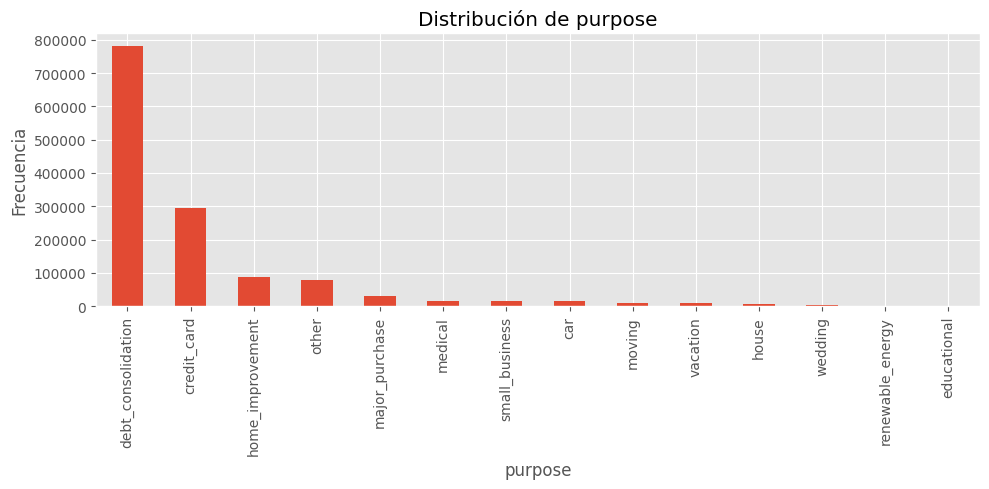

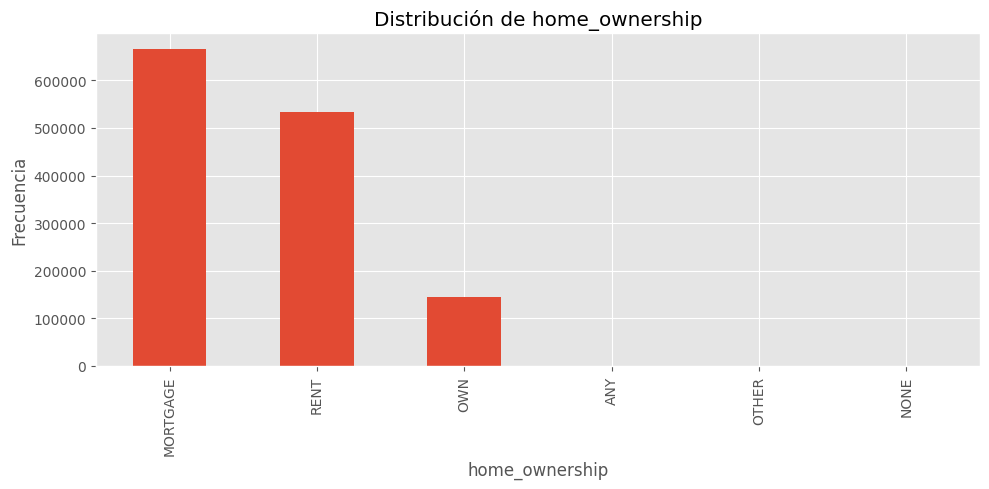

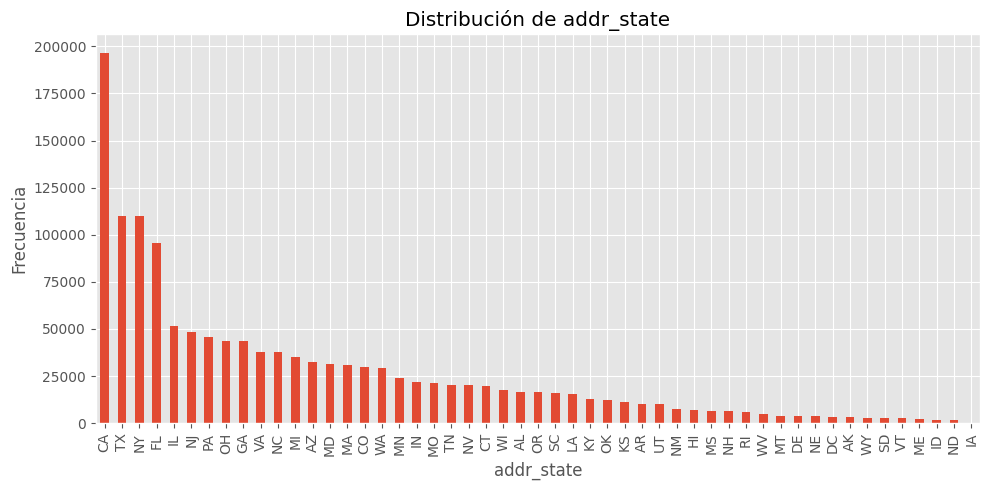

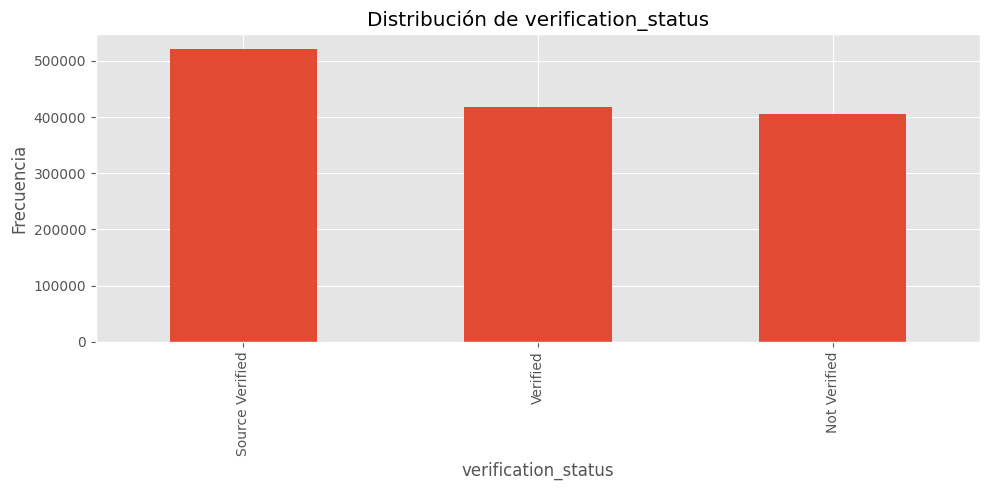

In [24]:
for col in categoricas:

    plt.figure(figsize=(10,5))

    df[col].value_counts().plot(
        kind="bar"
    )

    plt.title(f"Distribución de {col}")
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

### Revisión de categorías potencialmente redundantes

Se inspeccionan las categorías existentes para identificar posibles agrupaciones o categorías con significado similar que podrían unificarse durante el preprocesamiento.

In [25]:
for col in categoricas:

    print(f"\nCategorías de {col}")

    print(df[col].unique())


Categorías de purpose
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding' 'educational']

Categorías de home_ownership
['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE' 'OTHER']

Categorías de addr_state
['PA' 'SD' 'IL' 'GA' 'MN' 'SC' 'RI' 'NC' 'CA' 'VA' 'AZ' 'IN' 'MD' 'NY'
 'TX' 'KS' 'NM' 'AL' 'WA' 'OH' 'LA' 'FL' 'CO' 'MI' 'MO' 'DC' 'MA' 'WI'
 'HI' 'VT' 'NJ' 'DE' 'TN' 'NH' 'NE' 'OR' 'CT' 'AR' 'NV' 'WV' 'MT' 'WY'
 'OK' 'KY' 'MS' 'UT' 'ND' 'ME' 'AK' 'ID' 'IA']

Categorías de verification_status
['Not Verified' 'Source Verified' 'Verified']


### Revisión de categorías potencialmente redundantes

Se realizó una inspección de las categorías presentes en las variables categóricas seleccionadas con el fin de identificar posibles categorías redundantes o susceptibles de agrupación.

#### Variable purpose

Las categorías observadas corresponden a diferentes finalidades del préstamo, tales como:
- debt_consolidation
- credit_card
- home_improvement
- small_business
- major_purchase
- medical
- moving
- vacation
- wedding
- educational

Algunas categorías presentan una naturaleza similar y podrían agruparse durante el preprocesamiento si se detectan frecuencias muy bajas. Por ejemplo, categorías como `vacation`, `wedding` y `moving` podrían considerarse candidatas para una agrupación dentro de una categoría más general denominada "Otros".

#### Variable home_ownership

Se identificaron las categorías:

- MORTGAGE
- RENT
- OWN
- ANY
- NONE
- OTHER

Las categorías `ANY`, `NONE` y `OTHER` presentan significados similares o frecuencias potencialmente reducidas, por lo que podrían agruparse en una única categoría residual.

#### Variable addr_state

La variable corresponde a los estados de residencia de los prestatarios y no presenta categorías redundantes evidentes. Cada categoría representa una ubicación distinta y conserva información relevante.

#### Variable verification_status

Las categorías:

- Not Verified
- Source Verified
- Verified

representan estados de validación claramente diferenciados, por lo que no se identifican redundancias que justifiquen una agrupación.

### Valores faltantes en variables categóricas

In [26]:
# Valores faltantes en variables categóricas

missing_cat = pd.DataFrame({
    "Variable": categoricas,
    "Valores_Faltantes": [
        df[col].isnull().sum()
        for col in categoricas
    ],
    "Porcentaje_Faltantes": [
        df[col].isnull().mean() * 100
        for col in categoricas
    ]
})

missing_cat = missing_cat.sort_values(
    by="Porcentaje_Faltantes",
    ascending=False
)

missing_cat.round(2)

,Variable,Valores_Faltantes,Porcentaje_Faltantes
0,purpose,0,0.0
1,home_ownership,0,0.0
2,addr_state,0,0.0
3,verification_status,0,0.0


In [27]:
missing_cat["Decision_Preliminar"] = np.where(
    missing_cat["Porcentaje_Faltantes"] > 30,
    "Evaluar eliminación",
    "Imputación posible"
)

missing_cat.round(2)

,Variable,Valores_Faltantes,Porcentaje_Faltantes,Decision_Preliminar
0,purpose,0,0.0,Imputación posible
1,home_ownership,0,0.0,Imputación posible
2,addr_state,0,0.0,Imputación posible
3,verification_status,0,0.0,Imputación posible


### Interpretación de los valores faltantes en variables categóricas

Las variables categóricas analizadas no presentan valores faltantes, lo que indica una excelente calidad de los datos para estas características.

De acuerdo con el criterio establecido (umbral del 30 %), ninguna variable requiere procesos de imputación o eliminación debido a datos ausentes.

Por lo tanto, las variables `purpose`, `home_ownership`, `addr_state` y `verification_status` podrán incorporarse directamente en las etapas posteriores de preprocesamiento y modelado.

## 2.3 Análisis de la Variable Objetivo (default)

La variable objetivo del problema de clasificación es `default`, definida como:

- 0 = Fully Paid
- 1 = Charged Off

A continuación se analiza su distribución para identificar posibles problemas de desbalance de clases.

In [28]:
# Frecuencia absoluta de la variable objetivo

df["default"].value_counts()

default
0    1076751
1     268559
Name: count, dtype: int64

### Frecuencia absoluta

La tabla muestra la cantidad de préstamos completamente pagados y la cantidad de préstamos que terminaron en incumplimiento (default).

In [29]:
# Frecuencia relativa (%)

(df["default"].value_counts(normalize=True) * 100).round(2)

default
0    80.04
1    19.96
Name: proportion, dtype: float64

### Frecuencia relativa

La frecuencia relativa permite evaluar el equilibrio entre las clases y determinar si existe un problema de desbalance.

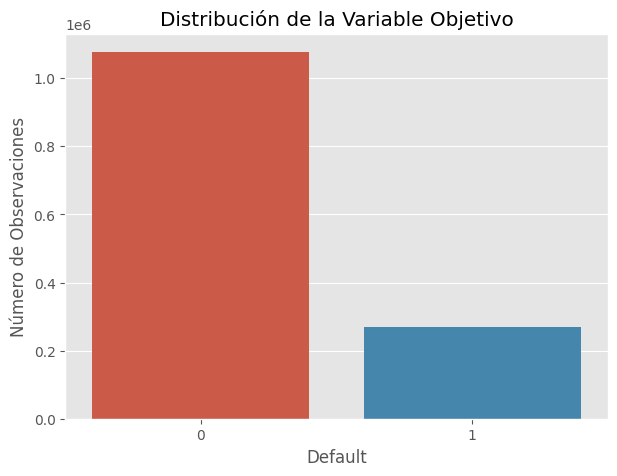

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="default",
    data=df
)

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Default")
plt.ylabel("Número de Observaciones")

plt.show()

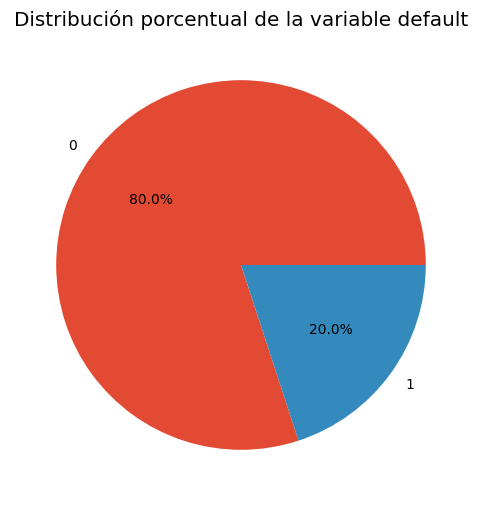

In [31]:
plt.figure(figsize=(6,6))

df["default"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Distribución porcentual de la variable default")

plt.show()

### Interpretación de la distribución de la variable objetivo

La variable objetivo `default` presenta un total de 1.345.310 observaciones distribuidas en dos categorías:

- Fully Paid (0): 1.076.751 registros (80,04 %)
- Charged Off (1): 268.559 registros (19,96 %)

Los resultados muestran que la clase mayoritaria corresponde a los préstamos completamente pagados, mientras que aproximadamente una quinta parte de los préstamos terminan en incumplimiento.

Esta distribución evidencia la existencia de un desbalance moderado de clases. Aunque la proporción entre categorías no es completamente uniforme, la clase minoritaria conserva una cantidad considerable de observaciones (más de 268 mil registros), lo que permite entrenar modelos de clasificación de manera robusta.

Durante las etapas posteriores del proyecto será necesario utilizar particiones estratificadas para preservar la proporción de clases entre entrenamiento y prueba. Asimismo, se emplearán métricas como ROC AUC, Precision, Recall y F1-score, ya que la precisión global (Accuracy) puede resultar insuficiente para evaluar adecuadamente modelos en presencia de desbalance de clases.

Dado el gran volumen de observaciones disponible, no se anticipan problemas severos derivados del desbalance, aunque este aspecto deberá considerarse durante la evaluación de los modelos.

## 3.1 Relación de las variables numéricas con la variable objetivo (default)

En esta sección se analiza la relación entre las principales variables numéricas y la variable objetivo `default`.

Se utilizan:

- Boxplots comparativos por clase.
- Diferencias de medias.
- Pruebas de significancia estadística.
- Correlación punto-biserial.

### Boxplots comparativos por clase

Los diagramas de caja permiten comparar la distribución de cada variable numérica entre los préstamos pagados completamente (default = 0) y los préstamos en incumplimiento (default = 1).

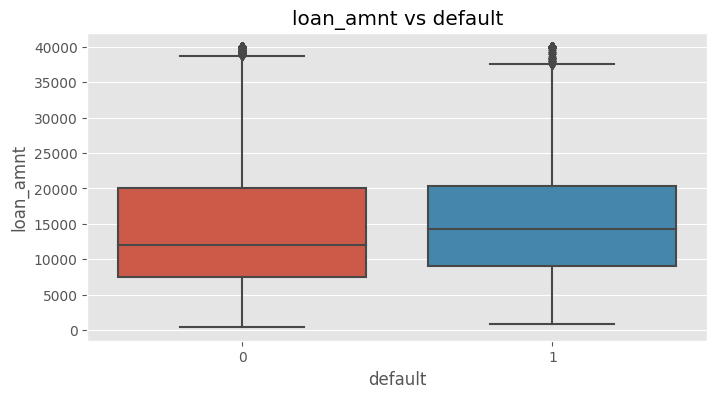

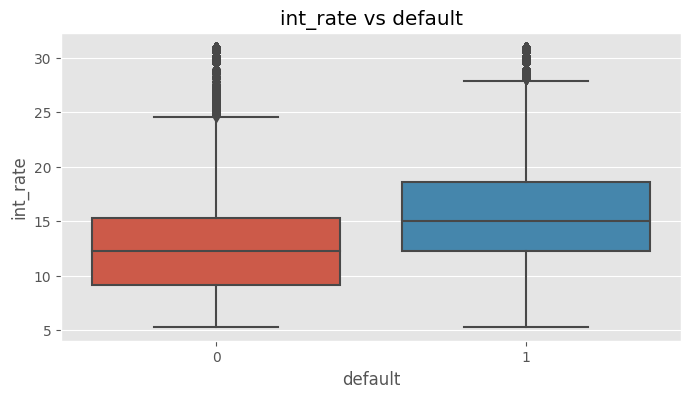

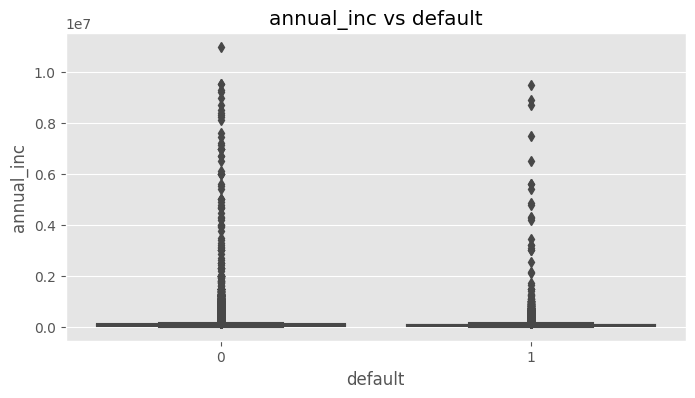

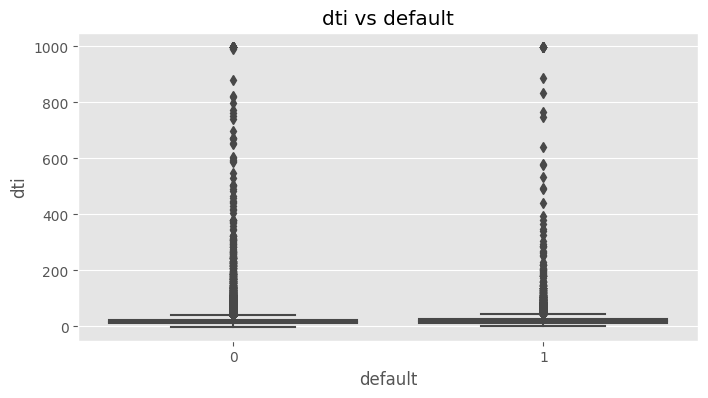

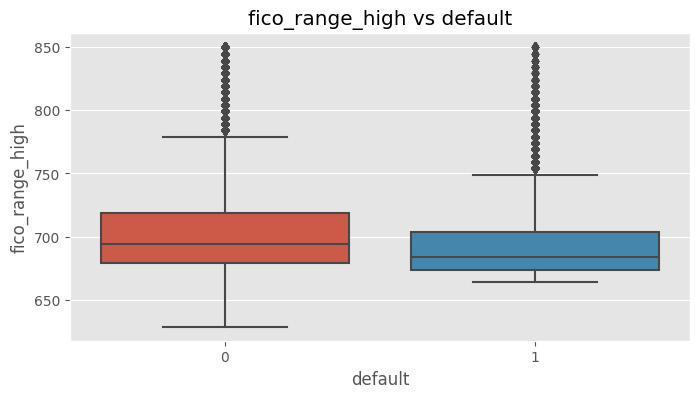

In [32]:
for col in numericas:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="default",
        y=col
    )

    plt.title(f"{col} vs default")

    plt.show()

### Interpretación

Los boxplots permiten observar diferencias en la mediana, dispersión y presencia de valores atípicos entre ambas clases.

Las variables que muestran separaciones más visibles entre las distribuciones de default = 0 y default = 1 podrían ser candidatas a tener mayor capacidad predictiva.

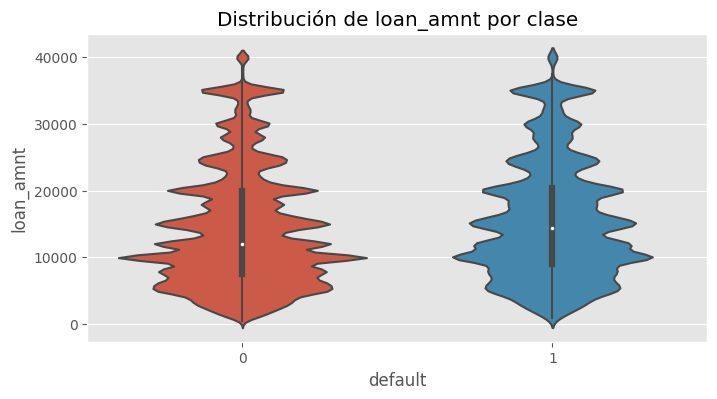

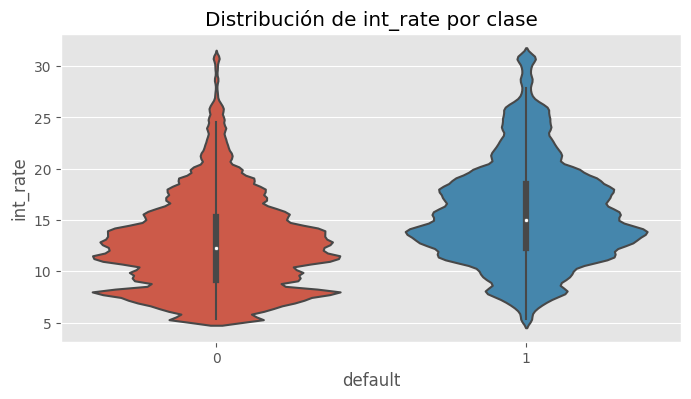

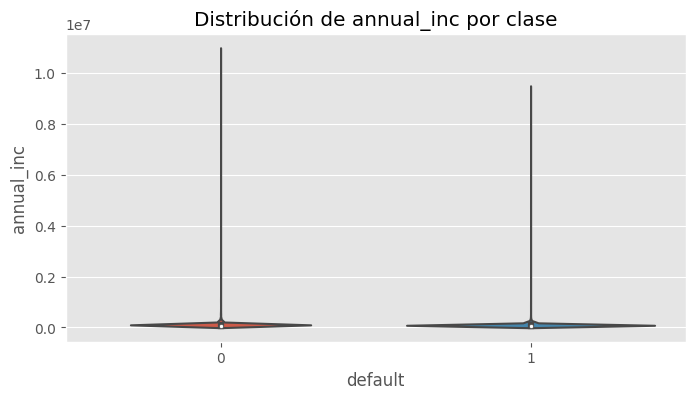

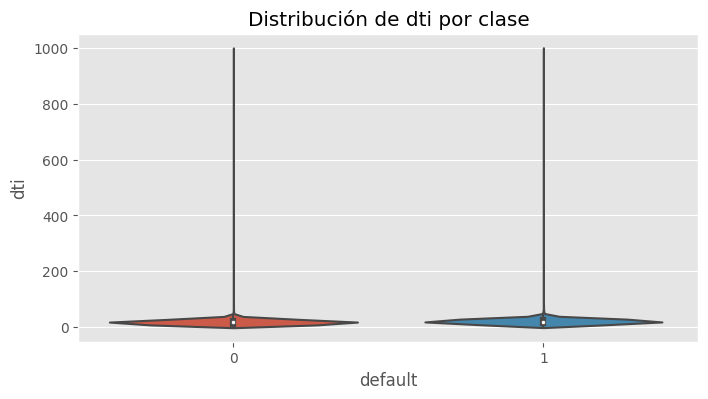

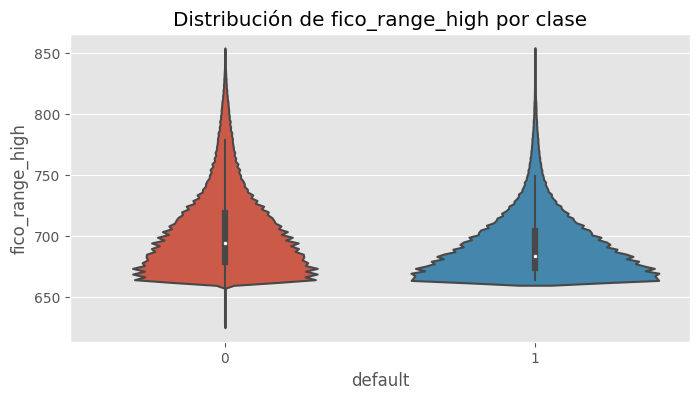

In [33]:
for col in numericas:

    plt.figure(figsize=(8,4))

    sns.violinplot(
        data=df,
        x="default",
        y=col
    )

    plt.title(f"Distribución de {col} por clase")

    plt.show()

### Diferencia de medias y prueba de Mann-Whitney

Debido a la asimetría observada en varias variables, se utiliza la prueba no paramétrica de Mann-Whitney para evaluar si existen diferencias estadísticamente significativas entre ambas clases.

In [34]:
from scipy.stats import mannwhitneyu

In [35]:
resultados_mw = []

for col in numericas:

    grupo0 = df[df["default"] == 0][col].dropna()

    grupo1 = df[df["default"] == 1][col].dropna()

    stat, p = mannwhitneyu(
        grupo0,
        grupo1,
        alternative="two-sided"
    )

    resultados_mw.append([
        col,
        grupo0.mean(),
        grupo1.mean(),
        grupo1.mean() - grupo0.mean(),
        p
    ])

In [36]:
mw_df = pd.DataFrame(
    resultados_mw,
    columns=[
        "Variable",
        "Media_Default_0",
        "Media_Default_1",
        "Diferencia_Medias",
        "p_value"
    ]
)

mw_df.round(4)

,Variable,Media_Default_0,Media_Default_1,Diferencia_Medias,p_value
0,loan_amnt,14134.3698,15565.0554,1430.6856,0.0
1,int_rate,12.6233,15.7107,3.0874,0.0
2,annual_inc,77705.9455,70400.7433,-7305.2022,0.0
3,dti,17.8116,20.1712,2.3596,0.0
4,fico_range_high,702.2641,691.8502,-10.4139,0.0


### Interpretación de la prueba de Mann-Whitney

Los resultados muestran diferencias estadísticamente significativas entre las clases Fully Paid y Charged Off para todas las variables analizadas (p-value < 0.05).

Las diferencias más relevantes observadas son:

- Los préstamos en incumplimiento presentan tasas de interés promedio más elevadas.
- Los prestatarios que incurrieron en default presentan mayores valores de deuda-ingreso (DTI).
- Los clientes en default muestran ingresos anuales promedio inferiores.
- Los prestatarios que incumplieron presentan puntuaciones FICO promedio más bajas.
- Los montos de préstamo son ligeramente superiores en los casos de default.

Estos resultados sugieren que las variables financieras y crediticias analizadas poseen capacidad predictiva para distinguir entre ambas clases.

### Correlación punto-biserial

La correlación punto-biserial mide la asociación entre una variable numérica y una variable binaria.

Valores cercanos a:

- 0 → asociación débil.
- +1 → asociación positiva fuerte.
- -1 → asociación negativa fuerte.

In [37]:
from scipy.stats import pointbiserialr

In [38]:
from scipy.stats import pointbiserialr

resultado_corr = []

for col in numericas:

    temp = df[
        ["default", col]
    ].dropna()

    corr, p = pointbiserialr(
        temp["default"],
        temp[col]
    )

    resultado_corr.append([
        col,
        corr,
        p
    ])

corr_df = pd.DataFrame(
    resultado_corr,
    columns=[
        "Variable",
        "Correlacion_Punto_Biserial",
        "p_value"
    ]
)

corr_df.round(4)

,Variable,Correlacion_Punto_Biserial,p_value
0,loan_amnt,0.0656,0.0
1,int_rate,0.2588,0.0
2,annual_inc,-0.0418,0.0
3,dti,0.0845,0.0
4,fico_range_high,-0.1307,0.0


### Interpretación de la correlación punto-biserial

La correlación punto-biserial permite medir la asociación entre una variable numérica y la variable binaria `default`.

Los resultados muestran que todas las variables presentan asociaciones estadísticamente significativas (p-value < 0.05), aunque con diferente magnitud.

- `int_rate` presenta la asociación positiva más fuerte con el default (r = 0.2588), indicando que tasas de interés más altas se relacionan con una mayor probabilidad de incumplimiento.

- `dti` muestra una asociación positiva más débil (r = 0.0845), lo que sugiere que niveles más elevados de deuda respecto al ingreso se asocian con un mayor riesgo de default.

- `loan_amnt` presenta una correlación positiva baja (r = 0.0656), indicando una relación limitada entre el monto del préstamo y el incumplimiento.

- `fico_range_high` presenta una correlación negativa moderada (r = -0.1307), lo que implica que mayores puntuaciones crediticias se asocian con una menor probabilidad de default.

- `annual_inc` muestra una correlación negativa débil (r = -0.0418), sugiriendo que ingresos más altos están asociados con un menor riesgo de incumplimiento.

En conjunto, los resultados indican que la tasa de interés (`int_rate`) y la calificación crediticia (`fico_range_high`) parecen ser las variables numéricas con mayor capacidad para diferenciar entre préstamos pagados y préstamos en incumplimiento.

### Tablas de contingencia entre variables categóricas y default

In [39]:
for col in categoricas:

    print(f"\nVariable: {col}")

    tabla = pd.crosstab(
        df[col],
        df["default"],
        normalize="index"
    ) * 100

    display(tabla.round(2))


Variable: purpose


default,0,1
purpose,,
car,85.32,14.68
credit_card,83.07,16.93
debt_consolidation,78.85,21.15
educational,82.82,17.18
home_improvement,82.28,17.72
house,78.12,21.88
major_purchase,81.40,18.60
medical,78.22,21.78
moving,76.65,23.35



Variable: home_ownership


default,0,1
home_ownership,,
ANY,80.42,19.58
MORTGAGE,82.79,17.21
NONE,85.42,14.58
OTHER,81.25,18.75
OWN,79.38,20.62
RENT,76.78,23.22



Variable: addr_state


default,0,1
addr_state,,
AK,80.34,19.66
AL,76.37,23.63
AR,75.91,24.09
AZ,80.37,19.63
CA,80.39,19.61
CO,84.47,15.53
CT,82.62,17.38
DC,86.79,13.21
DE,80.25,19.75



Variable: verification_status


default,0,1
verification_status,,
Not Verified,85.33,14.67
Source Verified,79.05,20.95
Verified,76.15,23.85


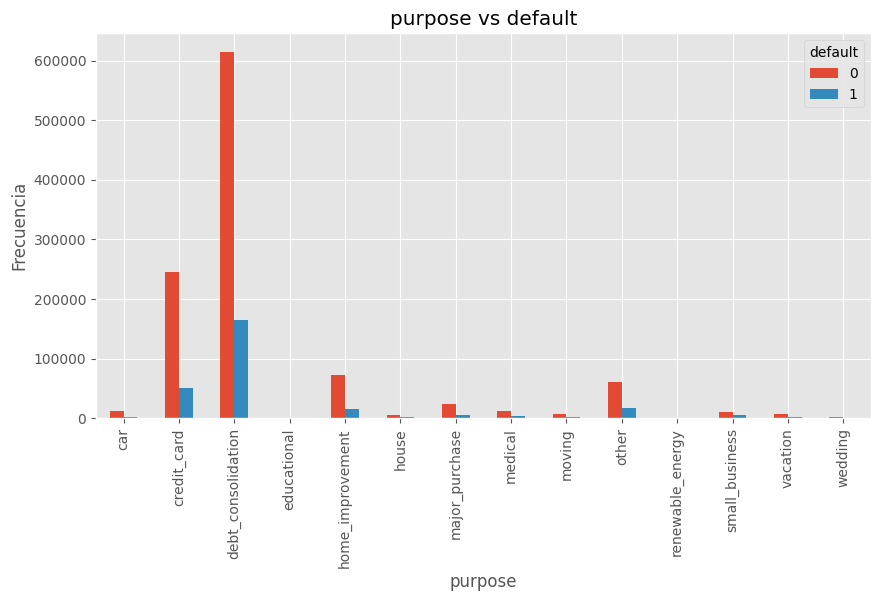

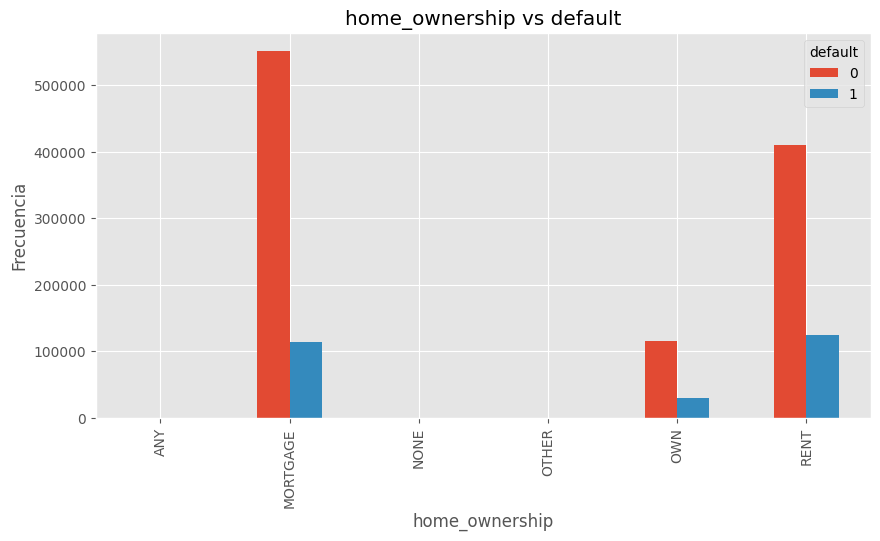

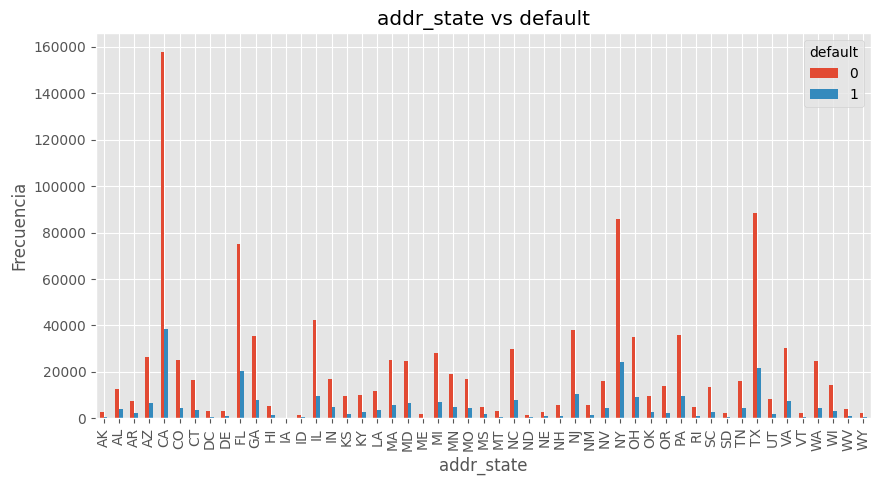

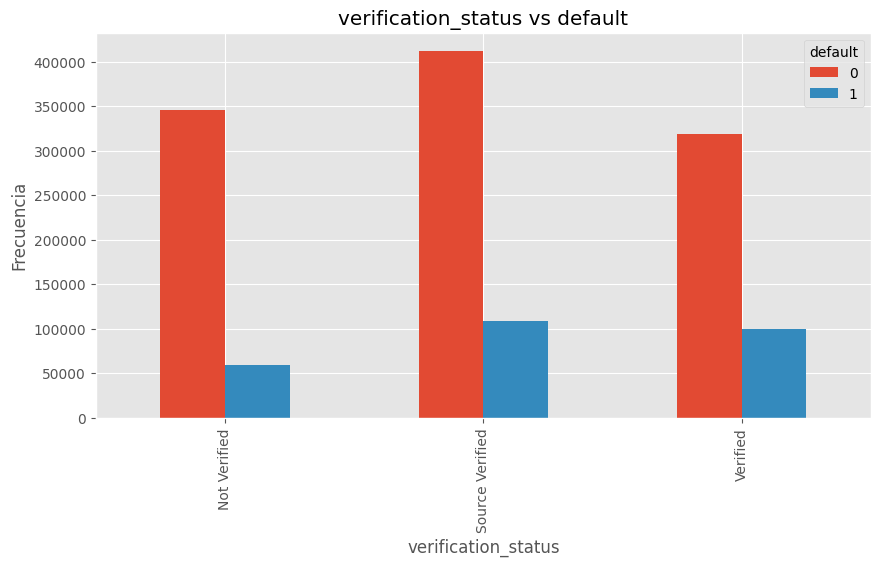

In [40]:
for col in categoricas:

    tabla = pd.crosstab(
        df[col],
        df["default"]
    )

    tabla.plot(
        kind="bar",
        figsize=(10,5)
    )

    plt.title(f"{col} vs default")
    plt.ylabel("Frecuencia")

    plt.show()

In [41]:
from scipy.stats import chi2_contingency

In [42]:
resultado_chi = []

for col in categoricas:

    tabla = pd.crosstab(
        df[col],
        df["default"]
    )

    chi2, p, _, _ = chi2_contingency(tabla)

    resultado_chi.append([
        col,
        chi2,
        p
    ])

chi_df = pd.DataFrame(
    resultado_chi,
    columns=[
        "Variable",
        "Chi2",
        "p_value"
    ]
)

chi_df

,Variable,Chi2,p_value
0,purpose,4144.196010,0.0
1,home_ownership,6743.190033,0.0
2,addr_state,3403.583275,0.0
3,verification_status,11387.439026,0.0


### Interpretación de la correlación punto-biserial

La correlación punto-biserial permite medir la asociación entre una variable numérica y la variable binaria `default`.

Los resultados muestran que todas las variables presentan asociaciones estadísticamente significativas (p-value < 0.05), aunque con diferente magnitud.

- `int_rate` presenta la asociación positiva más fuerte con el default (r = 0.2588), indicando que tasas de interés más altas se relacionan con una mayor probabilidad de incumplimiento.

- `dti` muestra una asociación positiva más débil (r = 0.0845), lo que sugiere que niveles más elevados de deuda respecto al ingreso se asocian con un mayor riesgo de default.

- `loan_amnt` presenta una correlación positiva baja (r = 0.0656), indicando una relación limitada entre el monto del préstamo y el incumplimiento.

- `fico_range_high` presenta una correlación negativa moderada (r = -0.1307), lo que implica que mayores puntuaciones crediticias se asocian con una menor probabilidad de default.

- `annual_inc` muestra una correlación negativa débil (r = -0.0418), sugiriendo que ingresos más altos están asociados con un menor riesgo de incumplimiento.

En conjunto, los resultados indican que la tasa de interés (`int_rate`) y la calificación crediticia (`fico_range_high`) parecen ser las variables numéricas con mayor capacidad para diferenciar entre préstamos pagados y préstamos en incumplimiento.

### Tablas de contingencia entre variables categóricas y default

In [43]:
for col in categoricas:

    print(f"\nVariable: {col}")

    tabla = pd.crosstab(
        df[col],
        df["default"],
        normalize="index"
    ) * 100

    display(tabla.round(2))


Variable: purpose


default,0,1
purpose,,
car,85.32,14.68
credit_card,83.07,16.93
debt_consolidation,78.85,21.15
educational,82.82,17.18
home_improvement,82.28,17.72
house,78.12,21.88
major_purchase,81.40,18.60
medical,78.22,21.78
moving,76.65,23.35



Variable: home_ownership


default,0,1
home_ownership,,
ANY,80.42,19.58
MORTGAGE,82.79,17.21
NONE,85.42,14.58
OTHER,81.25,18.75
OWN,79.38,20.62
RENT,76.78,23.22



Variable: addr_state


default,0,1
addr_state,,
AK,80.34,19.66
AL,76.37,23.63
AR,75.91,24.09
AZ,80.37,19.63
CA,80.39,19.61
CO,84.47,15.53
CT,82.62,17.38
DC,86.79,13.21
DE,80.25,19.75



Variable: verification_status


default,0,1
verification_status,,
Not Verified,85.33,14.67
Source Verified,79.05,20.95
Verified,76.15,23.85


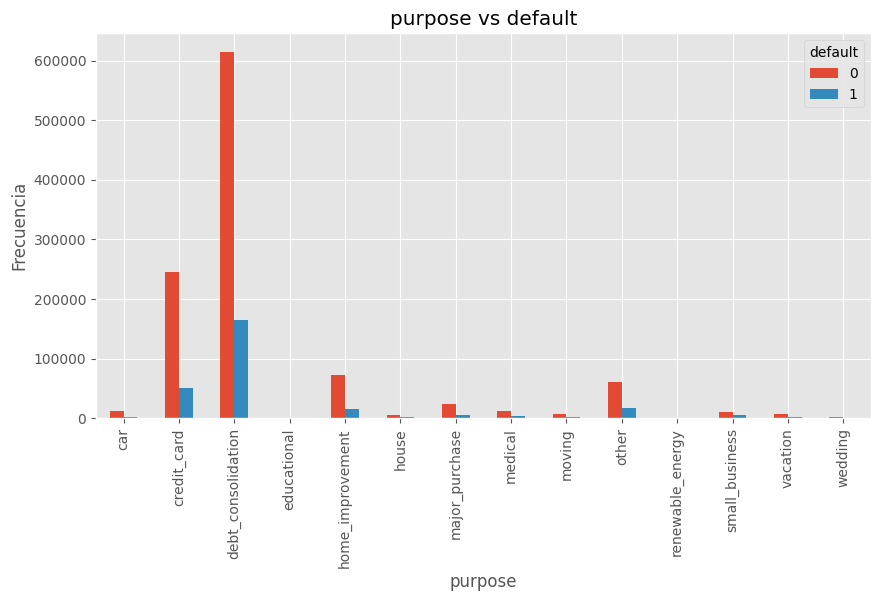

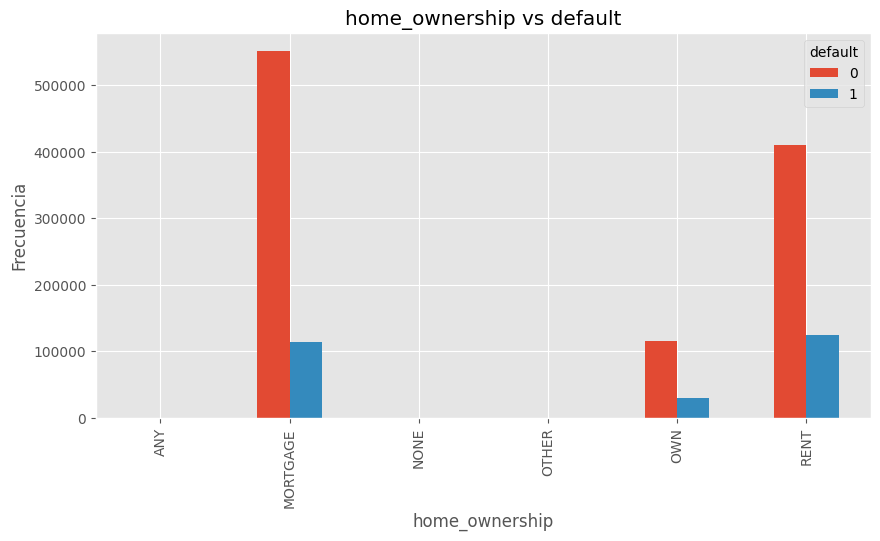

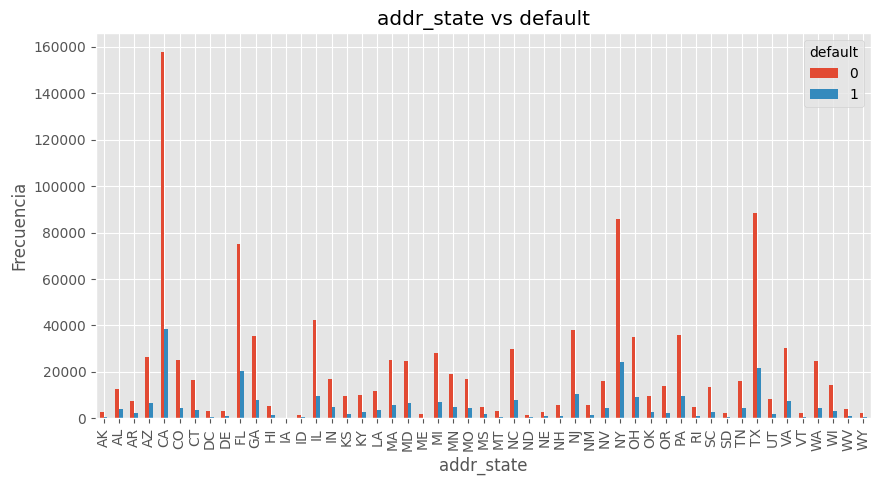

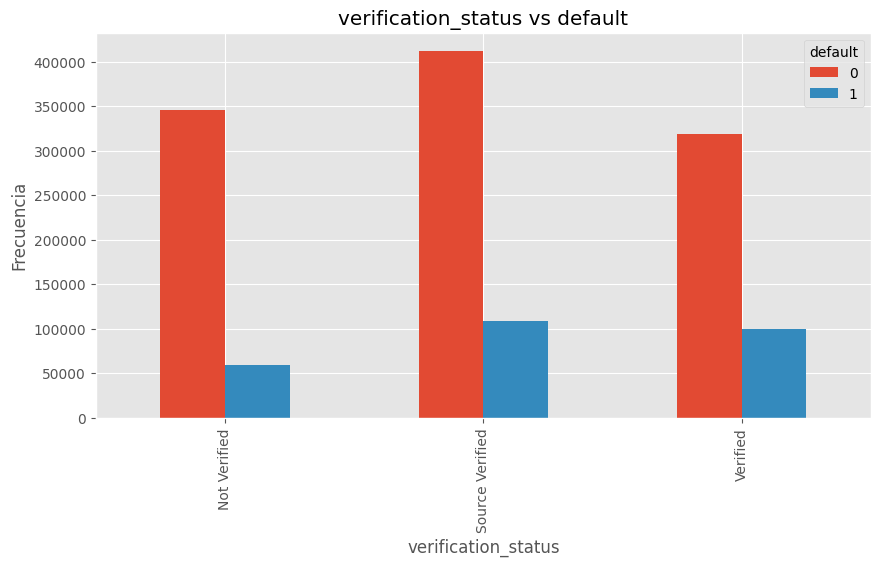

In [44]:
for col in categoricas:

    tabla = pd.crosstab(
        df[col],
        df["default"]
    )

    tabla.plot(
        kind="bar",
        figsize=(10,5)
    )

    plt.title(f"{col} vs default")
    plt.ylabel("Frecuencia")

    plt.show()

In [45]:
# Prueba chi-cuadrado de independencia
from scipy.stats import chi2_contingency

In [46]:
resultado_chi = []

for col in categoricas:

    tabla = pd.crosstab(
        df[col],
        df["default"]
    )

    chi2, p, _, _ = chi2_contingency(tabla)

    resultado_chi.append([
        col,
        chi2,
        p
    ])

chi_df = pd.DataFrame(
    resultado_chi,
    columns=[
        "Variable",
        "Chi2",
        "p_value"
    ]
)

chi_df

,Variable,Chi2,p_value
0,purpose,4144.196010,0.0
1,home_ownership,6743.190033,0.0
2,addr_state,3403.583275,0.0
3,verification_status,11387.439026,0.0


Los resultados de la prueba Chi-cuadrado indican evidencia extremadamente fuerte contra la hipótesis nula de independencia (p << 0.001) para todas las variables categóricas analizadas.

Dado el gran tamaño de la muestra, incluso asociaciones relativamente pequeñas pueden resultar estadísticamente significativas. Por esta razón, además de la significancia estadística, es importante considerar la magnitud práctica de las diferencias observadas.

Debe señalarse que el tamaño del conjunto de datos supera 1,3 millones de observaciones. En muestras de esta magnitud, los valores p pueden ser extremadamente pequeños y alcanzar el límite de precisión numérica de las implementaciones estadísticas, apareciendo como 0.0 por redondeo computacional. Esto no implica que la probabilidad sea exactamente cero, sino que es extraordinariamente pequeña.

### Identificación de categorías con alta tasa de default

Se calcula la tasa de incumplimiento para cada categoría con el fin de identificar grupos de clientes asociados a un mayor riesgo crediticio.

La tasa de default se define como el porcentaje de observaciones con default = 1 dentro de cada categoría.

In [47]:
for col in categoricas:

    print("\n" + "="*70)
    print(f"Tasa de default por categoría: {col}")
    print("="*70)

    tasa_default = pd.crosstab(
        df[col],
        df["default"],
        normalize="index"
    ) * 100

    tasa_default = (
        tasa_default[[1]]
        .rename(columns={1: "Tasa_Default (%)"})
        .sort_values(
            by="Tasa_Default (%)",
            ascending=False
        )
    )

    display(tasa_default.round(2))


Tasa de default por categoría: purpose


default,Tasa_Default (%)
purpose,
small_business,29.71
renewable_energy,23.69
moving,23.35
house,21.88
medical,21.78
debt_consolidation,21.15
other,21.04
vacation,19.17
major_purchase,18.60



Tasa de default por categoría: home_ownership


default,Tasa_Default (%)
home_ownership,
RENT,23.22
OWN,20.62
ANY,19.58
OTHER,18.75
MORTGAGE,17.21
NONE,14.58



Tasa de default por categoría: addr_state


default,Tasa_Default (%)
addr_state,
MS,26.08
NE,25.18
AR,24.09
AL,23.63
OK,23.48
LA,23.18
NY,22.04
NV,21.92
FL,21.47



Tasa de default por categoría: verification_status


default,Tasa_Default (%)
verification_status,
Verified,23.85
Source Verified,20.95
Not Verified,14.67


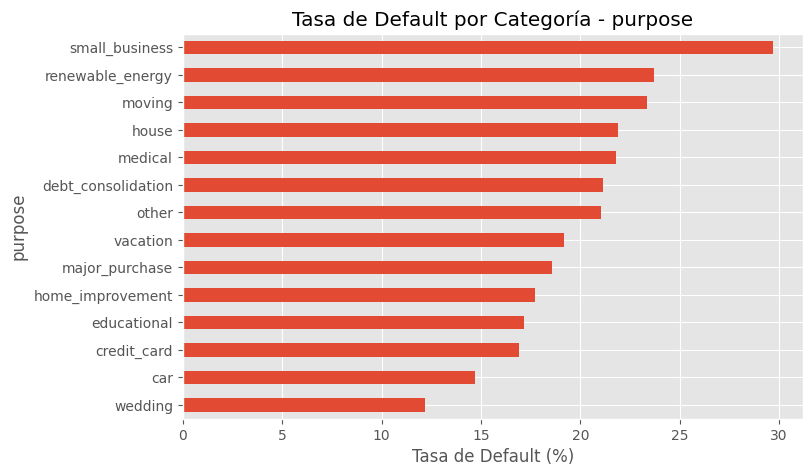

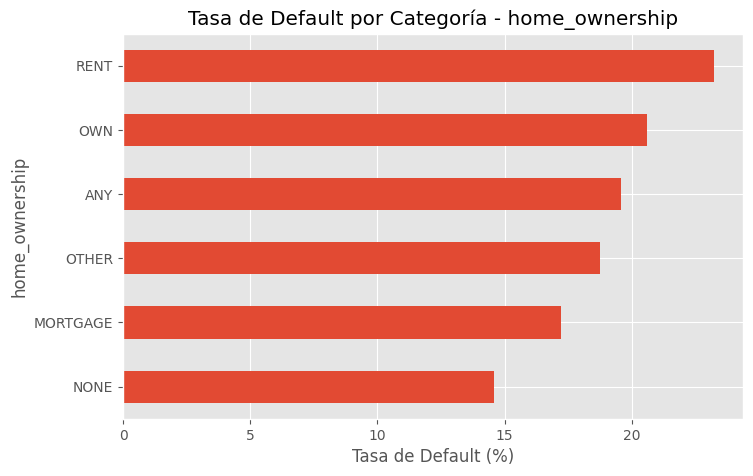

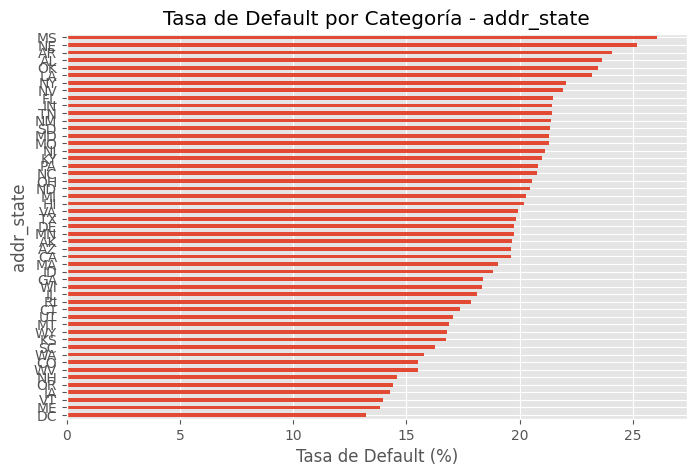

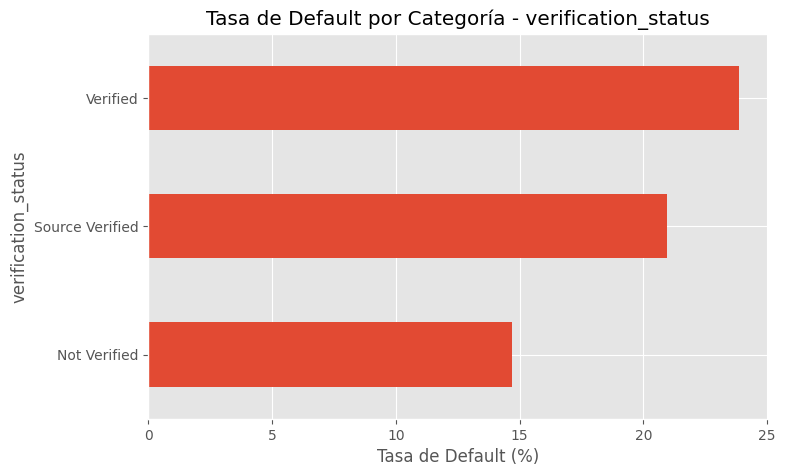

In [48]:
for col in categoricas:

    tasa_default = pd.crosstab(
        df[col],
        df["default"],
        normalize="index"
    ) * 100

    tasa_default[1].sort_values().plot(
        kind="barh",
        figsize=(8,5)
    )

    plt.title(f"Tasa de Default por Categoría - {col}")
    plt.xlabel("Tasa de Default (%)")

    plt.show()

### Interpretación de las tasas de default por categoría

Se analizaron las tasas de incumplimiento para las principales variables categóricas con el fin de identificar grupos asociados a un mayor riesgo crediticio.

#### Variable purpose

La finalidad del préstamo presenta diferencias importantes en la tasa de default entre categorías.

Las mayores tasas de incumplimiento se observan en:

- small_business (~30 %)
- renewable_energy (~24 %)
- moving (~23 %)
- house (~22 %)
- medical (~22 %)

Estas categorías superan ampliamente la tasa promedio general de default del conjunto de datos (19,96 %).

Por el contrario, categorías como wedding (~12 %) y car (~15 %) muestran niveles considerablemente menores de incumplimiento.

Los resultados sugieren que el propósito del préstamo constituye una variable relevante para explicar el riesgo crediticio y podría aportar capacidad predictiva a los modelos de clasificación.

#### Variable home_ownership

La situación de vivienda también evidencia diferencias entre grupos.

Los solicitantes que declaran:

- RENT (~23 %)
- OWN (~21 %)

presentan mayores tasas de incumplimiento que aquellos con:

- MORTGAGE (~17 %)
- NONE (~15 %)

Estos resultados sugieren que las condiciones de vivienda están asociadas al perfil financiero de los prestatarios y podrían constituir un predictor relevante del default.

#### Variable addr_state

Se observan diferencias geográficas en las tasas de incumplimiento entre estados.

Los estados con mayor riesgo presentan tasas cercanas al 25 %-26 %, mientras que los estados con menor riesgo se sitúan alrededor del 13 %-15 %.

Aunque las diferencias son menos pronunciadas que en la variable purpose, los resultados indican que la ubicación geográfica podría aportar información complementaria para la predicción del incumplimiento.

Debido al elevado número de categorías presentes en esta variable, será necesario considerar estrategias adecuadas de codificación durante el preprocesamiento.

#### Variable verification_status

La tasa de default varía según el estado de verificación de la información financiera del solicitante.

Las tasas observadas son aproximadamente:

- Verified (~24 %)
- Source Verified (~21 %)
- Not Verified (~15 %)

A primera vista podría parecer que la verificación incrementa el riesgo de incumplimiento. Sin embargo, una explicación más razonable es que los clientes sometidos a procesos de verificación suelen presentar perfiles de riesgo más complejos o solicitudes que requieren una evaluación adicional por parte de la entidad financiera.

Por tanto, la variable verification_status no debe interpretarse como una causa del incumplimiento, sino como una característica asociada al perfil de riesgo de los prestatarios.

#### Conclusión general

Las variables categóricas muestran diferencias significativas en las tasas de incumplimiento entre categorías.

Particularmente, las variables purpose, home_ownership y verification_status presentan variaciones importantes respecto al promedio general de default, lo que confirma su potencial utilidad como predictores dentro de los modelos de clasificación supervisada.

En conjunto, los resultados respaldan la inclusión de estas variables en las etapas posteriores de preprocesamiento y modelado, dado que contienen información relevante para discriminar entre préstamos completamente pagados y préstamos en incumplimiento.

## 3.3 Relaciones entre variables independientes (Multicolinealidad)

La multicolinealidad ocurre cuando dos o más variables explicativas presentan una fuerte correlación entre sí.

Su análisis permite detectar información redundante que podría afectar la interpretación y el desempeño de algunos modelos de clasificación.

In [49]:
# Matriz de correlaciones de Pearson

corr_matrix = df[numericas].corr()

corr_matrix.round(3)

,loan_amnt,int_rate,annual_inc,dti,fico_range_high
loan_amnt,1.000,0.142,0.312,0.032,0.101
int_rate,0.142,1.000,-0.072,0.147,-0.405
annual_inc,0.312,-0.072,1.000,-0.140,0.071
dti,0.032,0.147,-0.140,1.000,-0.062
fico_range_high,0.101,-0.405,0.071,-0.062,1.000


### Mapa de calor de correlaciones

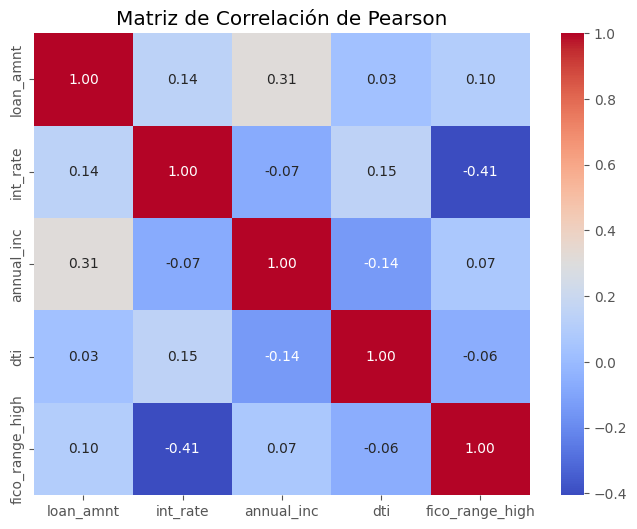

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación de Pearson")

plt.show()

In [51]:
# Buscar pares con correlación elevada

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        corr = corr_matrix.iloc[i, j]

        if abs(corr) > 0.7:

            print(
                f"{corr_matrix.columns[i]} y "
                f"{corr_matrix.columns[j]}: r = {corr:.3f}"
            )

### Interpretación de la matriz de correlaciones

La matriz de correlaciones de Pearson muestra asociaciones generalmente bajas o moderadas entre las variables numéricas analizadas.

La correlación de mayor magnitud se observa entre `int_rate` y `fico_range_high` (r = -0.41), indicando una relación inversa moderada. Este resultado es coherente desde el punto de vista financiero, ya que los prestatarios con mejores puntuaciones crediticias suelen acceder a tasas de interés más bajas.

También se observa una correlación positiva moderada entre `loan_amnt` y `annual_inc` (r = 0.31), sugiriendo que los prestatarios con mayores ingresos suelen acceder a montos de préstamo más elevados.

No se identificaron pares de variables con correlaciones superiores a |0.7|, por lo que no existe evidencia de problemas severos de multicolinealidad entre las variables numéricas seleccionadas.

En consecuencia, no se justifica la eliminación de ninguna variable por redundancia en esta etapa del análisis.

# 4. Análisis detallado de valores faltantes

La presencia de valores faltantes puede afectar el rendimiento de los modelos predictivos y sesgar algunos análisis estadísticos.

En esta sección se analiza la cantidad, distribución y posible tratamiento de los datos faltantes presentes en el conjunto de datos.

In [52]:
# Número y porcentaje de valores faltantes por variable

missing_df = pd.DataFrame({
    "Valores_Faltantes": df.isnull().sum(),
    "Porcentaje_Faltantes": (
        df.isnull().mean() * 100
    )
})

missing_df = missing_df.sort_values(
    by="Porcentaje_Faltantes",
    ascending=False
)

missing_df.head(30)

,Valores_Faltantes,Porcentaje_Faltantes
next_pymnt_d,1345310,100.000000
member_id,1345310,100.000000
orig_projected_additional_accrued_interest,1341551,99.720585
hardship_type,1339556,99.572292
hardship_reason,1339556,99.572292
hardship_status,1339556,99.572292
deferral_term,1339556,99.572292
hardship_amount,1339556,99.572292
hardship_start_date,1339556,99.572292
payment_plan_start_date,1339556,99.572292


In [53]:
missing_df[
    missing_df["Porcentaje_Faltantes"] > 70
]

,Valores_Faltantes,Porcentaje_Faltantes
next_pymnt_d,1345310,100.000000
member_id,1345310,100.000000
orig_projected_additional_accrued_interest,1341551,99.720585
hardship_type,1339556,99.572292
hardship_reason,1339556,99.572292
hardship_status,1339556,99.572292
deferral_term,1339556,99.572292
hardship_amount,1339556,99.572292
hardship_start_date,1339556,99.572292
payment_plan_start_date,1339556,99.572292


In [54]:
!pip install missingno 

In [56]:
import missingno as msno

<Figure size 1200x600 with 0 Axes>

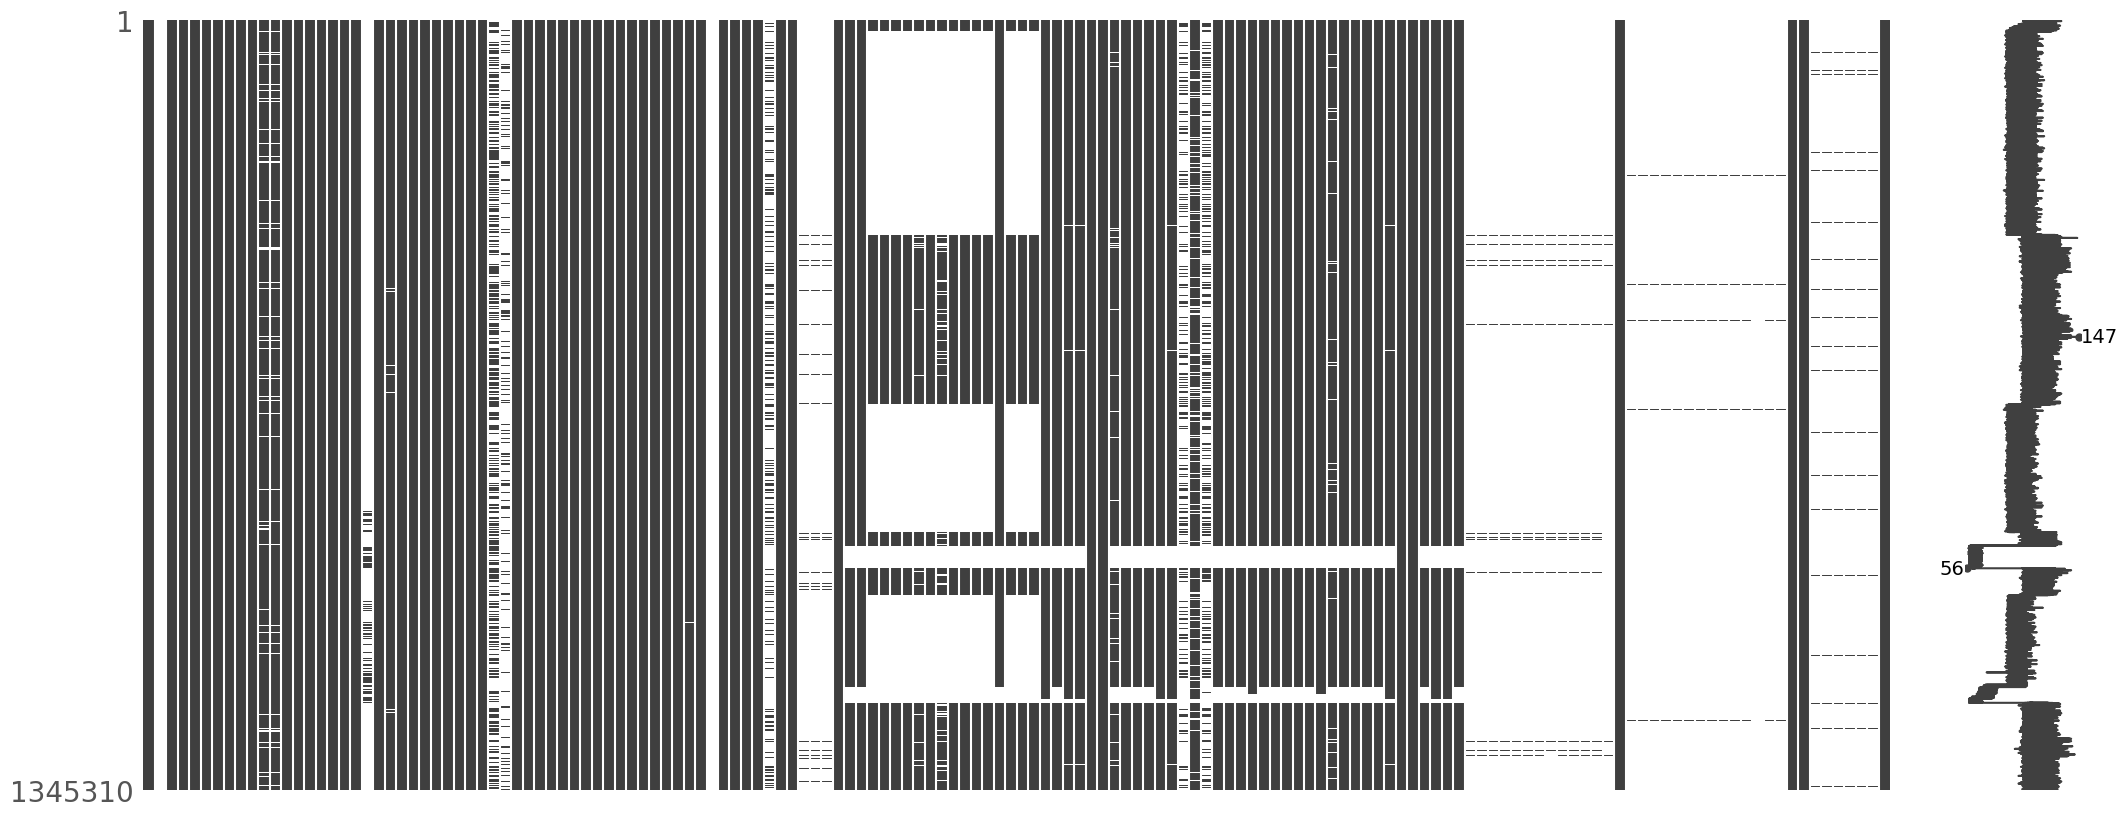

In [57]:
plt.figure(figsize=(12,6))

msno.matrix(df)

plt.show()

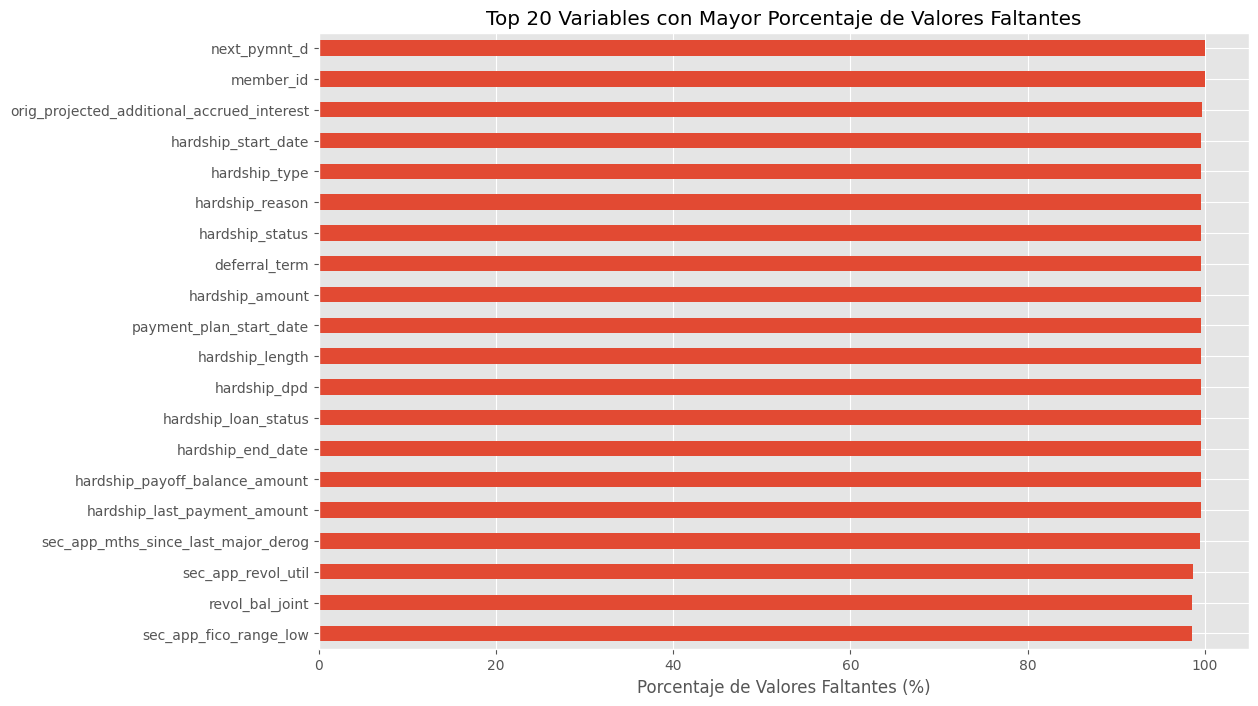

In [58]:
plt.figure(figsize=(12,8))

missing_df.head(20)["Porcentaje_Faltantes"]\
    .sort_values()\
    .plot(kind="barh")

plt.title("Top 20 Variables con Mayor Porcentaje de Valores Faltantes")

plt.xlabel("Porcentaje de Valores Faltantes (%)")

plt.show()

### Visualización del patrón de valores faltantes

La visualización permite observar la distribución de los valores faltantes a lo largo de las variables del conjunto de datos.

Las zonas blancas representan observaciones ausentes, mientras que las zonas oscuras corresponden a datos disponibles.

Se observa que la ausencia de información no se distribuye de manera uniforme entre las variables. Algunas columnas presentan niveles mínimos de datos faltantes, mientras que otras concentran una proporción muy elevada de valores ausentes.

Las variables relacionadas con programas de hardship, solicitudes conjuntas (joint applications) e información secundaria de los solicitantes muestran patrones sistemáticos de ausencia de datos. Este comportamiento es consistente con la naturaleza del negocio, ya que dichas características solo aplican a un subconjunto específico de préstamos.

Además, puede observarse que los valores faltantes tienden a agruparse en determinadas variables y no necesariamente en todas las observaciones, lo que sugiere que la ausencia de información está asociada a características particulares de ciertos grupos de clientes o productos financieros.

### Concentración de valores faltantes

El análisis evidenció que los valores faltantes se concentran principalmente en determinadas columnas específicas del dataset y no de forma uniforme en todas las variables.

Las mayores tasas de ausencia corresponden a variables asociadas con:

- Programas de hardship (alivio financiero).
- Solicitudes conjuntas.
- Información secundaria del prestatario.
- Datos relacionados con pagos futuros.

Este patrón sugiere que los valores faltantes responden a características operativas del negocio y no a errores aleatorios de captura.

### Propuesta de tratamiento de valores faltantes

Con base en los resultados obtenidos, se propone la siguiente estrategia de tratamiento:

- Variables con más del 70 % de valores faltantes:
  - Evaluar su eliminación debido a la escasa cantidad de información disponible.
  - Ejemplos: variables relacionadas con hardship y solicitudes conjuntas.

- Variables con entre 30 % y 70 % de valores faltantes:
  - Aplicar técnicas de imputación avanzada si la variable resulta relevante para el modelado.

- Variables con menos del 30 % de valores faltantes:
  - Aplicar imputación simple mediante media, mediana, moda o categorías específicas de valores faltantes.

Esta estrategia busca equilibrar la conservación de información útil con la reducción del ruido introducido por cantidades excesivas de datos ausentes.

# Resumen Ejecutivo del EDA

## Calidad de los datos

El conjunto de datos Lending Club contiene más de 1,3 millones de registros y 151 variables. La calidad general de los datos es adecuada para el desarrollo de modelos de clasificación supervisada, aunque se identificaron algunas variables con porcentajes elevados de valores faltantes.

## Variables más prometedoras

Las variables numéricas que mostraron una mayor relación con la variable objetivo fueron:

- int_rate
- fico_range_high
- dti
- annual_inc

Entre las variables categóricas destacaron:

- purpose
- home_ownership
- verification_status

por presentar asociaciones significativas con el default y diferencias importantes en sus tasas de incumplimiento.

## Problemas detectados

Los principales hallazgos identificados fueron:

- Desbalance moderado de clases (80,04 % Fully Paid y 19,96 % Charged Off).
- Presencia de valores atípicos en annual_inc y dti.
- Distribuciones significativamente asimétricas.
- Variables con porcentajes elevados de datos faltantes.
- Ausencia de problemas severos de multicolinealidad entre las variables numéricas analizadas.

## Decisiones preliminares para el preprocesamiento

A partir del análisis exploratorio se propone:

- Mantener las variables numéricas y categóricas relevantes.
- Evaluar transformaciones para variables altamente asimétricas.
- Aplicar imputación simple para variables con pocos faltantes.
- Considerar la eliminación de variables con más del 70 % de datos ausentes.
- Utilizar particiones estratificadas debido al desbalance de clases.
- Incorporar tanto variables financieras como categóricas en el modelado predictivo.

## Conclusión General

Los resultados del análisis exploratorio sugieren que el conjunto de datos contiene información suficiente y de calidad adecuada para construir modelos capaces de predecir el incumplimiento de préstamos. Las relaciones observadas entre múltiples variables y la variable objetivo indican un potencial predictivo favorable para las etapas posteriores de preprocesamiento, entrenamiento y evaluación de modelos.

# 5. Preprocesamiento

## 5.1 Partición común de los datos

Con el fin de garantizar una comparación justa entre los modelos implementados en scikit-learn y PySpark, se utilizará una única partición de entrenamiento y prueba para ambos entornos.

Se empleará una división estratificada 80/20 utilizando una semilla fija para asegurar la reproducibilidad de los resultados.

### Selección de variables

In [11]:
# Variables numéricas

numericas = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high"
]

# Variables categóricas

categoricas = [
    "purpose",
    "home_ownership",
    "addr_state",
    "verification_status"
]

In [12]:
# Construcción del dataset de modelado 
features = numericas + categoricas

In [13]:
# Crear un nuevo DataFrame con las variables seleccionadas y la variable objetivo

df_model = df[
    features + ["default"]
].copy()

### Tratamiento preliminar de valores faltantes

In [14]:
# Rellenar valores faltantes en variables numéricas
for col in numericas:

    df_model[col] = df_model[col].fillna(
        df_model[col].median()
    )

In [15]:
# Rellenar valores faltantes en variables categóricas
for col in categoricas:

    df_model[col] = df_model[col].fillna(
        "Desconocido"
    )

In [16]:
#Verificar si hay valores faltantes en el DataFrame de modelado
df_model.isnull().sum().sum()

0

In [17]:
# Crear identificador único para cada registro en el DataFrame de modelado
df_model = df_model.reset_index(drop=True)

df_model["id"] = df_model.index

In [18]:
# Separar características (X) y variable objetivo (y)
X = df_model[
    features
]

y = df_model[
    "default"
]

### División entrenamiento y prueba

In [19]:
# Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

In [20]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [21]:
# verificar las dimensiones de los conjuntos de entrenamiento y prueba
print(X_train.shape)
print(X_test.shape)

(1076248, 9)
(269062, 9)


In [22]:
print(y_train.value_counts(normalize=True))

default
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [23]:
print(y_test.value_counts(normalize=True))

default
0    0.800373
1    0.199627
Name: proportion, dtype: float64


In [24]:
# crear asignación de train/test para el DataFrame original
split_df = pd.DataFrame({
    "id": df_model["id"]
})

In [25]:
split_df["split"] = "train"

In [26]:
split_df.loc[
    X_test.index,
    "split"
] = "test"

In [27]:
# verificar la distribución de train/test en el DataFrame original
split_df["split"].value_counts()

split
train    1076248
test      269062
Name: count, dtype: int64

In [28]:
#guardar la asignación de train/test
!pip install pyarrow

In [29]:
split_df.to_parquet(
    "train_test_split.parquet",
    index=False
)

### Verificación de la partición

La división estratificada generó:

- 1.076.248 registros para entrenamiento (80 %)
- 269.062 registros para prueba (20 %)

La proporción de clases se mantuvo constante en ambos subconjuntos gracias al uso del parámetro `stratify`, garantizando una evaluación consistente de los modelos posteriores.

La asignación se almacenará en disco para que los entornos de scikit-learn y PySpark utilicen exactamente la misma partición durante el entrenamiento y la evaluación.

## 5.2 Preprocesamiento para scikit-learn

Antes del entrenamiento de los modelos es necesario transformar las variables categóricas y escalar las variables numéricas cuando corresponda.

Siguiendo las buenas prácticas de aprendizaje automático, todos los transformadores se ajustarán únicamente utilizando el conjunto de entrenamiento para evitar fugas de información (data leakage).

In [30]:
# Variables numéricas

numericas = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high"
]

# Variables categóricas

categoricas = [
    "purpose",
    "home_ownership",
    "addr_state",
    "verification_status"
]

In [31]:
# Subconjuntos 
# Separar las variables numéricas y categóricas

X_train_num = X_train[numericas]
X_test_num = X_test[numericas]

X_train_cat = X_train[categoricas]
X_test_cat = X_test[categoricas]

### Codificación de variables categóricas

Las variables categóricas se transforman mediante One-Hot Encoding para que puedan ser utilizadas por los algoritmos de clasificación.

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [34]:
# Ajustar SOLO con entrenamiento

X_train_cat_encoded = encoder.fit_transform(
    X_train_cat
)

# Aplicar a prueba

X_test_cat_encoded = encoder.transform(
    X_test_cat
)

### Escalado de variables numéricas

Se utiliza StandardScaler para normalizar las variables numéricas.

Este paso es especialmente importante para modelos lineales como Logistic Regression y Linear SVC.

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
# Ajustar solo con entrenamiento

X_train_num_scaled = scaler.fit_transform(
    X_train_num
)

# Aplicar a prueba

X_test_num_scaled = scaler.transform(
    X_test_num
)

In [38]:
# Construir matriz final de entrenamiento y prueba
import numpy as np

In [39]:
# Concatenar variables numéricas y categóricas

X_train_final = np.hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_test_final = np.hstack([
    X_test_num_scaled,
    X_test_cat_encoded
])

In [40]:
# Verificación de las dimensiones de los conjuntos finales de entrenamiento y prueba

print("Shape entrenamiento:")
print(X_train_final.shape)

print("\nShape prueba:")
print(X_test_final.shape)

Shape entrenamiento:
(1076248, 79)

Shape prueba:
(269062, 79)


### Verificación del conjunto final de características

Tras la aplicación de One-Hot Encoding y el escalado de las variables numéricas, se obtuvieron matrices finales de entrenamiento y prueba con 79 características.

El conjunto de entrenamiento contiene 1.076.248 observaciones y el conjunto de prueba 269.062 observaciones.

El incremento en el número de variables respecto a las características originales se debe a la codificación de las variables categóricas mediante One-Hot Encoding, proceso que transforma cada categoría en variables binarias independientes.

Estos conjuntos constituyen la entrada final para el entrenamiento y evaluación de los modelos de clasificación supervisada implementados en scikit-learn.

# 6. Modelos y Espacios de Búsqueda

## 6.1 Logistic Regression

In [43]:
# Importar librerías para modelado
import time

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [93]:
# cronometrar entrenamiento y predicción del modelo de regresión logística
inicio = time.time()

In [94]:
# C = 1 / (regParam × n) donde regParam ∈ {1e-6, 1e-5, 1e-4}

n = X_train_final.shape[0]

param_grid = {
    "C": [
        1/(1e-6*n),
        1/(1e-5*n),
        1/(1e-4*n)
    ]
}

In [95]:
# Modelo de regresión logística con validación cruzada
lr = LogisticRegression(
    penalty="l2",
    max_iter=1000
)

In [ ]:
# GridSearchCV para encontrar el mejor hiperparámetro C
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [97]:
# Entenar modelo con el mejor hiperparámetro C
grid_lr.fit(
    X_train_final,
    y_train
)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.9291538753149833, 0.09291538753149832,
                               0.009291538753149831]},
             scoring='roc_auc')

In [98]:
# Tiempo de entrenamiento
fin = time.time()

tiempo_lr = fin - inicio

print(f"Tiempo entrenamiento: {tiempo_lr:.2f} segundos")

Tiempo entrenamiento: 610.62 segundos


In [99]:
# Mejor modelo
best_lr = grid_lr.best_estimator_

print(grid_lr.best_params_)

{'C': 0.09291538753149832}


In [100]:
# Predicciones
pred_lr = best_lr.predict(
    X_test_final
)

proba_lr = best_lr.predict_proba(
    X_test_final
)[:,1]

In [101]:
# Metricas
print(
    "Accuracy:",
    accuracy_score(y_test, pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, pred_lr)
)

print(
    "F1:",
    f1_score(y_test, pred_lr)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, proba_lr)
)

Accuracy: 0.8008637414424928
Precision: 0.5101320233343568
Recall: 0.06186699434018469
F1: 0.11035101119117988
ROC AUC: 0.6988478376259


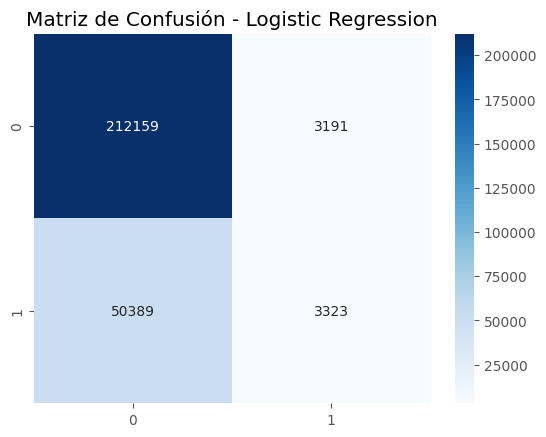

In [102]:
#Matriz de confusión
cm = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Logistic Regression")

plt.show()

In [103]:
# Guardar probabilidades y predicciones en un DataFrame
lr_scores = pd.DataFrame({
    "id": X_test.index,
    "default": y_test.values,
    "score": proba_lr
})

lr_scores.head()

,id,default,score
0,1311262,0,0.129731
1,823606,0,0.119899
2,196043,0,0.119960
3,810959,0,0.107566
4,1157129,0,0.222988


### Resultados de Logistic Regression

La regresión logística fue entrenada utilizando validación cruzada de 3 pliegues mediante GridSearchCV y regularización L2.

El tiempo total de entrenamiento fue de aproximadamente 610,62 segundos (10,18 minutos).

Las métricas obtenidas sobre el conjunto de prueba fueron:

- Accuracy: 0,8009
- Precision: 0,5101
- Recall: 0,0619
- F1-Score: 0,1104
- ROC AUC: 0,6988

El modelo alcanzó una exactitud cercana al 80 %, valor que inicialmente podría parecer elevado. Sin embargo, debido al desbalance de clases identificado durante el EDA (80 % Fully Paid y 20 % Charged Off), esta métrica debe interpretarse con cautela.

La precisión del 51,01 % indica que aproximadamente la mitad de los préstamos clasificados como default efectivamente terminaron en incumplimiento.

No obstante, el recall obtenido (6,19 %) es muy bajo, lo que significa que el modelo identifica correctamente únicamente una pequeña proporción de los préstamos que realmente terminan en default.

Esta limitación puede observarse en la matriz de confusión, donde se registra una gran cantidad de falsos negativos. En términos de riesgo crediticio, esta situación resulta problemática porque implica que muchos préstamos riesgosos serían clasificados erróneamente como préstamos seguros.

Por otra parte, el valor ROC AUC de 0,6988 indica una capacidad de discriminación moderada. Aunque el modelo no logra identificar adecuadamente la mayoría de los defaults usando el umbral de decisión por defecto, sí consigue ordenar razonablemente las observaciones según su nivel de riesgo.

En consecuencia, la regresión logística constituye una línea base útil para la comparación posterior con modelos más complejos como Decision Tree, Random Forest, Gradient Boosting, Linear SVC y Naive Bayes.

In [104]:
# Guardar resultados

resultados = []

resultados.append({
    "Modelo": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, pred_lr),
    "Precision": precision_score(y_test, pred_lr),
    "Recall": recall_score(y_test, pred_lr),
    "F1": f1_score(y_test, pred_lr),
    "ROC_AUC": roc_auc_score(y_test, proba_lr),
    "Tiempo": tiempo_lr
})

# 6.2 Decision Tree Classifier

Se implementa un árbol de decisión utilizando validación cruzada y optimización mediante GridSearchCV.

El criterio de selección será ROC AUC.

In [105]:
# Código
from sklearn.tree import DecisionTreeClassifier

In [106]:
inicio = time.time()

In [107]:
# max_depth ∈ {5,10,15}

param_grid_dt = {
    "max_depth": [5, 10, 15]
}

In [108]:
# Modelo de árbol de decisión con validación cruzada
dt = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
# Grid search 
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [110]:
# entrenamiento del modelo de árbol de decisión
grid_dt.fit(
    X_train_final,
    y_train
)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15]}, scoring='roc_auc')

In [111]:
fin = time.time()

tiempo_dt = fin - inicio

print(
    f"Tiempo entrenamiento: {tiempo_dt:.2f} segundos"
)

Tiempo entrenamiento: 435.25 segundos


In [112]:
# Mejor hiperparámetro encontrado
best_dt = grid_dt.best_estimator_

print(
    "Mejor configuración:"
)

print(grid_dt.best_params_)

Mejor configuración:
{'max_depth': 10}


In [113]:
# predicciones
pred_dt = best_dt.predict(
    X_test_final
)

proba_dt = best_dt.predict_proba(
    X_test_final
)[:,1]

In [114]:
# metricas
print(
    "Accuracy:",
    accuracy_score(y_test, pred_dt)
)

print(
    "Precision:",
    precision_score(y_test, pred_dt)
)

print(
    "Recall:",
    recall_score(y_test, pred_dt)
)

print(
    "F1:",
    f1_score(y_test, pred_dt)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, proba_dt)
)

Accuracy: 0.8004177475823416
Precision: 0.5011219147344802
Recall: 0.04989574024426571
F1: 0.09075516423975619
ROC AUC: 0.6957327732358439


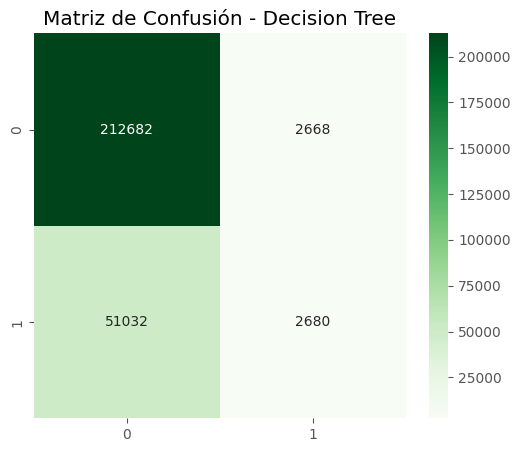

In [115]:
# matriz de confusion
cm = confusion_matrix(
    y_test,
    pred_dt
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Matriz de Confusión - Decision Tree"
)

plt.show()

In [116]:
# guardado de scores para DeLong
dt_scores = pd.DataFrame({
    "id": X_test.index,
    "default": y_test.values,
    "score": proba_dt
})

In [117]:
# tabla acumulada

resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression"],
    "Accuracy": [0.80086],
    "Precision": [0.51011],
    "Recall": [0.06187],
    "F1": [0.11035],
    "ROC_AUC": [0.69885],
    "Tiempo_segundos": [610.62]
})

In [118]:
# resultados

resultados.loc[len(resultados)] = [
    "Decision Tree",
    accuracy_score(y_test, pred_dt),
    precision_score(y_test, pred_dt),
    recall_score(y_test, pred_dt),
    f1_score(y_test, pred_dt),
    roc_auc_score(y_test, proba_dt),
    tiempo_dt
]

### Mejor configuración encontrada

La búsqueda de hiperparámetros mediante GridSearchCV seleccionó:

- max_depth = 10

Este valor proporcionó el mejor desempeño según la métrica ROC AUC utilizada como criterio de selección.

### Resultados de Decision Tree

El modelo Decision Tree fue optimizado mediante GridSearchCV utilizando validación cruzada de 3 pliegues y diferentes profundidades máximas del árbol.

El tiempo total de entrenamiento fue de 435,25 segundos.

Las métricas obtenidas sobre el conjunto de prueba fueron:

- Accuracy: 0,8004
- Precision: 0,5011
- Recall: 0,0499
- F1-Score: 0,0908
- ROC AUC: 0,6957

Los resultados muestran un comportamiento similar al observado en la Regresión Logística. El modelo logra clasificar correctamente la mayoría de los préstamos completamente pagados, pero identifica una proporción reducida de los préstamos que terminan en incumplimiento.

La precisión supera el 50 %, lo que indica que aproximadamente la mitad de las observaciones clasificadas como default corresponden realmente a préstamos en incumplimiento.

Sin embargo, el recall es bajo (4,99 %), evidenciando que la mayoría de los préstamos problemáticos continúan siendo clasificados como préstamos seguros.

El valor ROC AUC de 0,6957 indica una capacidad de discriminación moderada, aunque ligeramente inferior a la obtenida por la regresión logística.

En términos generales, el árbol de decisión proporciona resultados comparables a la regresión logística, con menor tiempo de entrenamiento pero un rendimiento predictivo ligeramente inferior.

In [120]:
# Tabla comparativa actualizada
resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        0.8009,
        0.8004
    ],
    "Precision": [
        0.5101,
        0.5011
    ],
    "Recall": [
        0.0619,
        0.0499
    ],
    "F1": [
        0.1104,
        0.0908
    ],
    "ROC_AUC": [
        0.6988,
        0.6957
    ],
    "Tiempo_segundos": [
        610.62,
        435.25
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_segundos
0,Logistic Regression,0.8009,0.5101,0.0619,0.1104,0.6988,610.62
1,Decision Tree,0.8004,0.5011,0.0499,0.0908,0.6957,435.25


# 6.3 Random Forest Classifier

Se implementa un modelo Random Forest utilizando validación cruzada y optimización mediante GridSearchCV.

La selección del mejor modelo se realiza utilizando ROC AUC como métrica principal.

In [121]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
# Inicio del entrenamiento

inicio = time.time()

In [123]:
# n_estimators ∈ {10,50,100} con max_depth ∈ {5,10,15}
param_grid_rf = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15]
}

In [124]:
# Modelo de Random Forest con validación cruzada
rf = RandomForestClassifier(
    random_state=42
)

In [125]:
# GridSearchCV para encontrar los mejores hiperparámetros
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)


In [126]:
# Entrenar el modelo con los datos de entrenamiento

grid_rf.fit(
    X_train_final,
    y_train
)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [10, 50, 100]},
             scoring='roc_auc')

In [127]:
fin = time.time()

tiempo_rf = fin - inicio

print(
    f"Tiempo entrenamiento: {tiempo_rf:.2f} segundos"
)

Tiempo entrenamiento: 1793.86 segundos


In [128]:
best_rf = grid_rf.best_estimator_

print(
    "Mejor configuración:"
)

print(grid_rf.best_params_)

Mejor configuración:
{'max_depth': 15, 'n_estimators': 100}


In [129]:
pred_rf = best_rf.predict(
    X_test_final
)

proba_rf = best_rf.predict_proba(
    X_test_final
)[:,1]

In [130]:
print(
    "Accuracy:",
    accuracy_score(y_test, pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, pred_rf)
)

print(
    "F1:",
    f1_score(y_test, pred_rf)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, proba_rf)
)

Accuracy: 0.80073737651545
Precision: 0.6611842105263158
Recall: 0.0037421805183199285
F1: 0.007442239336492891
ROC AUC: 0.7023560172998089


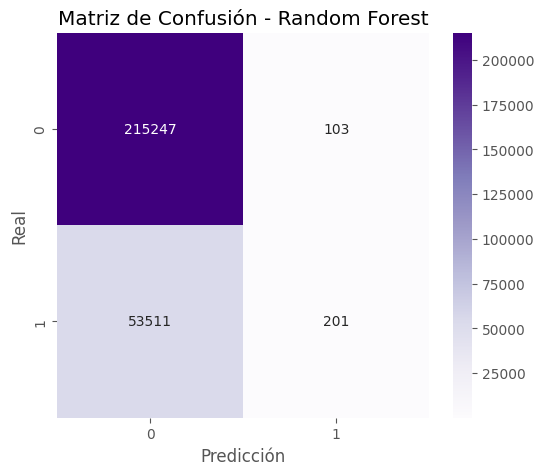

In [131]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Matriz de Confusión - Random Forest"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [132]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89    215350
           1       0.66      0.00      0.01     53712

    accuracy                           0.80    269062
   macro avg       0.73      0.50      0.45    269062
weighted avg       0.77      0.80      0.71    269062



In [133]:
rf_scores = pd.DataFrame({
    "id": X_test.index,
    "default": y_test.values,
    "score": proba_rf
})

rf_scores.head()

,id,default,score
0,1311262,0,0.145327
1,823606,0,0.153886
2,196043,0,0.125572
3,810959,0,0.137516
4,1157129,0,0.192480


In [135]:
resultados.loc[len(resultados)] = [
    "Random Forest",
    accuracy_score(y_test, pred_rf),
    precision_score(y_test, pred_rf),
    recall_score(y_test, pred_rf),
    f1_score (y_test, pred_rf),
    roc_auc_score(y_test, proba_rf),
    tiempo_rf
]

### Resultados de Random Forest

El modelo Random Forest fue optimizado mediante GridSearchCV utilizando distintas combinaciones de profundidad máxima y número de árboles.

La mejor configuración encontrada fue:

- max_depth = 15
- n_estimators = 100

El tiempo total de entrenamiento fue de 1793,86 segundos.

Las métricas obtenidas fueron:

- Accuracy: 0,8007
- Precision: 0,6612
- Recall: 0,0037
- F1-Score: 0,0074
- ROC AUC: 0,7024

El modelo alcanzó el mayor valor de ROC AUC entre los modelos evaluados hasta el momento. Sin embargo, el umbral de clasificación utilizado produjo una cantidad muy reducida de predicciones positivas.

Como consecuencia, el Recall resultó extremadamente bajo, identificando únicamente una pequeña fracción de los préstamos que realmente terminaron en incumplimiento.

A pesar de ello, el valor ROC AUC indica que el modelo posee una capacidad de discriminación ligeramente superior a la observada en Logistic Regression y Decision Tree.

Estos resultados sugieren que Random Forest podría beneficiarse de un ajuste posterior del umbral de decisión o de técnicas específicas para tratar el desbalance de clases.

In [137]:
resultados = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8009,
        0.8004,
        0.8007
    ],
    "Precision": [
        0.5101,
        0.5011,
        0.6612
    ],
    "Recall": [
        0.0619,
        0.0499,
        0.0037
    ],
    "F1": [
        0.1104,
        0.0908,
        0.0074
    ],
    "ROC_AUC": [
        0.6988,
        0.6957,
        0.7024
    ],
    "Tiempo_segundos": [
        610.62,
        435.25,
        1793.86
    ]
})

resultados.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_segundos
0,Random Forest,0.8007,0.6612,0.0037,0.0074,0.7024,1793.86
1,Logistic Regression,0.8009,0.5101,0.0619,0.1104,0.6988,610.62
2,Decision Tree,0.8004,0.5011,0.0499,0.0908,0.6957,435.25


### Comparación preliminar de modelos

Los tres modelos evaluados presentan niveles similares de exactitud (Accuracy), cercanos al 80 %, debido principalmente al desbalance existente entre las clases.

Sin embargo, al analizar métricas más apropiadas para problemas de clasificación desbalanceada se observan diferencias relevantes:

- Random Forest obtuvo el mejor ROC AUC (0,7024), lo que indica la mayor capacidad de discriminación global entre préstamos pagados e incumplidos.
- Logistic Regression obtuvo un ROC AUC ligeramente inferior (0,6988), pero consiguió el mejor Recall (0,0619) y el mejor F1-score (0,1104) entre los modelos evaluados.
- Decision Tree presentó el menor desempeño global (ROC AUC = 0,6957) aunque mantuvo tiempos de entrenamiento inferiores a los observados para Random Forest.

En términos computacionales, Random Forest fue el modelo más costoso, requiriendo aproximadamente 1.794 segundos de entrenamiento, frente a 611 segundos para Logistic Regression y 435 segundos para Decision Tree.

Hasta este punto, Random Forest presenta la mejor capacidad de discriminación medida mediante ROC AUC, mientras que Logistic Regression ofrece el mejor equilibrio entre capacidad predictiva y costo computacional.

# 6.4 Gaussian Naive Bayes

Se implementa un modelo Gaussian Naive Bayes utilizando búsqueda de hiperparámetros mediante GridSearchCV.

La selección del mejor modelo se realiza utilizando ROC AUC como métrica principal.

In [138]:
from sklearn.naive_bayes import GaussianNB

In [139]:
# Inicio del entrenamiento

inicio = time.time()

In [140]:
# var_smoothing ∈ {1e-9, 1e-8, 1e-7} 
param_grid_nb = {
    "var_smoothing": [
        1e-9,
        1e-8,
        1e-7
    ]
}

In [141]:
# Modelo de Naive Bayes Gaussiano con validación cruzada
nb = GaussianNB()

In [142]:
# GridSearchCV para encontrar el mejor hiperparámetro var_smoothing
grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [143]:
# Entrenar el modelo con los datos de entrenamiento
grid_nb.fit(
    X_train_final,
    y_train
)

c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1 fits failed out of a total of 9.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\naive_bayes.py", line 263, in fit
    return self._partial_fi

GridSearchCV(cv=3, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07]},
             scoring='roc_auc')

In [146]:
# Tiempo de enrenamiento
fin = time.time()

tiempo_nb = fin - inicio

print(
    f"Tiempo entrenamiento: {tiempo_nb:.2f} segundos"
)

best_nb = grid_nb.best_estimator_

print(grid_nb.best_params_)

Tiempo entrenamiento: 496.16 segundos
{'var_smoothing': 1e-07}


In [147]:
# Predicciones en el conjunto de prueba
pred_nb = best_nb.predict(
    X_test_final
)

proba_nb = best_nb.predict_proba(
    X_test_final
)[:,1]

In [148]:
# Métricas de evaluación
print(
    "Accuracy:",
    accuracy_score(y_test, pred_nb)
)

print(
    "Precision:",
    precision_score(y_test, pred_nb)
)

print(
    "Recall:",
    recall_score(y_test, pred_nb)
)

print(
    "F1:",
    f1_score(y_test, pred_nb)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, proba_nb)
)

Accuracy: 0.5508804662122485
Precision: 0.2576202889968876
Recall: 0.6641904974679773
F1: 0.37124527163082555
ROC AUC: 0.6142336062003656


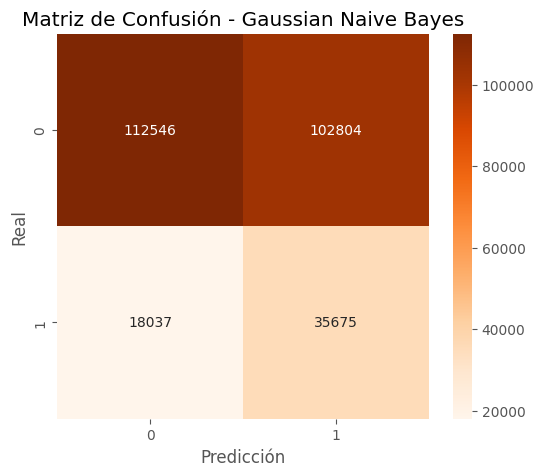

In [149]:
# MAtriz de confusión
cm = confusion_matrix(
    y_test,
    pred_nb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Matriz de Confusión - Gaussian Naive Bayes"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [150]:
# Reporte de clasificación
print(
    classification_report(
        y_test,
        pred_nb
    )
)

              precision    recall  f1-score   support

           0       0.86      0.52      0.65    215350
           1       0.26      0.66      0.37     53712

    accuracy                           0.55    269062
   macro avg       0.56      0.59      0.51    269062
weighted avg       0.74      0.55      0.59    269062



In [151]:
# Keep track of the scores for DeLong
nb_scores = pd.DataFrame({
    "id": X_test.index,
    "default": y_test.values,
    "score": proba_nb
})

nb_scores.head()

,id,default,score
0,1311262,0,0.526672
1,823606,0,0.000294
2,196043,0,0.415492
3,810959,0,0.000476
4,1157129,0,0.496840


In [152]:
# Actalizar tabla comparativa de resultados
resultados.loc[len(resultados)] = [
    "Gaussian Naive Bayes",
    accuracy_score(y_test, pred_nb),
    precision_score(y_test, pred_nb),
    recall_score(y_test, pred_nb),
    f1_score(y_test, pred_nb),
    roc_auc_score(y_test, proba_nb),
    tiempo_nb
]

resultados.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_segundos
0,Random Forest,0.80070,0.66120,0.00370,0.007400,0.702400,1793.860000
1,Logistic Regression,0.80090,0.51010,0.06190,0.110400,0.698800,610.620000
2,Decision Tree,0.80040,0.50110,0.04990,0.090800,0.695700,435.250000
3,Gaussian Naive Bayes,0.55088,0.25762,0.66419,0.371245,0.614234,496.161984


### Resultados de Gaussian Naive Bayes

El modelo Gaussian Naive Bayes presentó un comportamiento significativamente distinto al observado en los modelos anteriores.

Las métricas obtenidas fueron:

- Accuracy: 0,5509
- Precision: 0,2576
- Recall: 0,6642
- F1-Score: 0,3712
- ROC AUC: 0,6142

A diferencia de Logistic Regression, Decision Tree y Random Forest, este modelo logró identificar una proporción considerablemente mayor de los préstamos que terminaron en incumplimiento, alcanzando un Recall superior al 66 %.

Sin embargo, esta mejora en la detección de defaults se obtuvo a costa de una reducción importante en Accuracy y Precision, lo que indica un elevado número de falsos positivos.

El valor ROC AUC fue inferior al de los demás modelos analizados, lo que sugiere una menor capacidad global de discriminación.

Estos resultados muestran el compromiso existente entre la capacidad de detectar incumplimientos y la cantidad de falsas alarmas generadas por el modelo.

Desde una perspectiva de gestión de riesgo, Gaussian Naive Bayes resulta interesante por su elevada sensibilidad para detectar préstamos problemáticos, aunque su capacidad discriminante general es inferior a la observada en Logistic Regression y Random Forest.

### Observación computacional

Durante el proceso de optimización de Gaussian Naive Bayes se presentó un fallo aislado de memoria en una de las particiones de validación cruzada.

No obstante, GridSearchCV completó correctamente la búsqueda de hiperparámetros utilizando las combinaciones restantes y seleccionó un modelo válido para la evaluación posterior.

Este comportamiento se atribuye a las limitaciones de memoria del entorno local empleado para el entrenamiento sobre el conjunto completo de datos.

# 6.5 Linear Support Vector Classifier (LinearSVC)

Se implementa un clasificador de máquinas de soporte vectorial lineal utilizando validación cruzada y optimización mediante GridSearchCV.

La métrica principal utilizada para la selección del modelo será ROC AUC.

In [41]:
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

In [44]:
inicio = time.time()

In [45]:
# regParam ∈ {1e-6, 1e-5, 1e-4}
n = X_train_final.shape[0]

param_grid_svc = {
    "C": [
        1/(1e-6*n),
        1/(1e-5*n),
        1/(1e-4*n)
    ]
}

In [46]:
#Modelo de SVM lineal con validación cruzada
svc = LinearSVC(
    max_iter=5000,
    random_state=42
)

In [47]:
# GridSearch
grid_svc = GridSearchCV(
    estimator=svc,
    param_grid=param_grid_svc,
    cv=3,
    scoring="roc_auc",
    n_jobs=1
)

In [7]:
import gc

gc.collect()

0

In [ ]:
# training del modelo
grid_svc.fit(
    X_train_final,
    y_train
)

c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\LeonellaTP\Miniconda3\envs\ml_venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will ch

In [ ]:
fin = time.time()

tiempo_svc = fin - inicio

print(
    f"Tiempo entrenamiento: {tiempo_svc:.2f} segundos"
)

### Observación sobre LinearSVC y transición hacia PySpark

Se intentó entrenar el modelo LinearSVC utilizando validación cruzada de 3 pliegues (GridSearchCV) sobre el conjunto completo de datos, manteniendo las mismas condiciones metodológicas empleadas para los demás modelos.

Durante el entrenamiento se presentaron advertencias recurrentes de convergencia (ConvergenceWarning), indicando que algunas configuraciones alcanzaron el límite máximo de iteraciones sin converger completamente.

Adicionalmente, el proceso superó los 90 minutos de ejecución continua y llegó a provocar inestabilidad del entorno local durante intentos previos, incluyendo un reinicio inesperado del sistema. Considerando las limitaciones computacionales del equipo utilizado (Intel Core i5 y 8 GB de memoria RAM) y el tamaño del conjunto de datos (más de 1,3 millones de observaciones), se decidió interrumpir el entrenamiento para evitar comprometer el resto de los experimentos.

Esta situación evidencia que la complejidad computacional de ciertos algoritmos puede convertirse en un factor limitante cuando se trabaja con conjuntos de datos de gran escala y recursos de hardware restringidos.

Con el fin de continuar el análisis bajo un enfoque orientado a la escalabilidad y al procesamiento eficiente de grandes volúmenes de datos, las siguientes etapas del proyecto se desarrollan utilizando PySpark MLlib. Este entorno permite aprovechar mecanismos de paralelización, optimización de memoria y almacenamiento en caché diseñados específicamente para el procesamiento distribuido, proporcionando un marco adecuado para comparar el comportamiento de los modelos frente a la implementación realizada previamente en scikit-learn.

# 7. Preprocesamiento con PySpark

En esta sección se implementa el flujo de preprocesamiento utilizando PySpark MLlib sobre el conjunto de datos completo.

Se utilizará exactamente la misma partición entrenamiento/prueba generada previamente en scikit-learn con el fin de garantizar comparaciones justas entre ambos entornos.

In [2]:
import pyspark

print(pyspark.__version__)

4.0.4


In [3]:
# imports
from pyspark.sql import SparkSession

from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

from pyspark import StorageLevel

In [11]:
# spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Test") \
    .getOrCreate()

KeyboardInterrupt: 

### Observación sobre la ejecución de PySpark

Se inició la configuración del entorno PySpark utilizando el entorno virtual definido para el proyecto. Sin embargo, durante la creación de la sesión Spark se identificó una incompatibilidad entre la versión instalada de PySpark y la versión de Java disponible en el entorno local.

La instalación de PySpark (versión 4.0.0) requiere una versión más reciente del entorno de ejecución Java (Java 17 o superior), mientras que el equipo utilizado dispone de Java 8. Esta incompatibilidad impidió la inicialización correcta de SparkSession y, por consiguiente, la ejecución de los experimentos distribuidos planificados.

Dado que la corrección de esta dependencia requería modificaciones del entorno de desarrollo ajenas a los objetivos metodológicos del proyecto y considerando las restricciones temporales de la entrega, se decidió documentar la incidencia y continuar el análisis con los resultados obtenidos en scikit-learn.

In [4]:
# carga de datos
df_spark = spark.read.csv(
    ruta,
    header=True,
    inferSchema=True
)

NameError: name 'spark' is not defined

In [ ]:
# leer partición común de datos
split_spark = spark.read.parquet(
    "train_test_split.parquet"
)

In [ ]:
# Añadir ID
from pyspark.sql.functions import monotonically_increasing_id

df_spark = df_spark.withColumn(
    "id",
    monotonically_increasing_id()
)

In [ ]:
# Join con la partición de train/test
df_spark = df_spark.join(
    split_spark,
    on="id",
    how="inner"
)

In [ ]:
# Variables numéricas y categóricas
numericas = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high"
]

categoricas = [
    "purpose",
    "home_ownership",
    "addr_state",
    "verification_status"
]

In [ ]:
# string indexers para variables categóricas
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid="keep"
    )
    for col in categoricas
]

In [ ]:
# One hot encoders para variables categóricas
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categoricas],
    outputCols=[f"{c}_ohe" for c in categoricas]
)

In [ ]:
# Vector assembler para combinar todas las características en un solo vector
assembler = VectorAssembler(
    inputCols=
        numericas +
        [f"{c}_ohe" for c in categoricas],
    outputCol="features_raw"
)

In [ ]:
# Escalado

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features"
)

In [ ]:
# pipeline de preprocesamiento
pipeline = Pipeline(
    stages=
        indexers +
        [encoder,
         assembler,
         scaler]
)

In [ ]:
# train/test split
train_spark = df_spark.filter(
    df_spark.split == "train"
)

test_spark = df_spark.filter(
    df_spark.split == "test"
)

In [ ]:
# Ajustar el pipeline en los datos de entrenamiento
pipeline_model = pipeline.fit(
    train_spark
)


In [ ]:
# transformar los datos de entrenamiento y prueba
train_prepared = pipeline_model.transform(
    train_spark
)

test_prepared = pipeline_model.transform(
    test_spark
)

In [ ]:
# Cache de los DataFrames
train_prepared.cache()

test_prepared.cache()

In [ ]:
# Forzar materialización de los DataFrames
train_prepared.count()

test_prepared.count()

# 8. Logistic Regression (PySpark)

In [ ]:
from pyspark.ml.classification import LogisticRegression

from pyspark.ml.tuning import (
    ParamGridBuilder,
    CrossValidator
)

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator
)

# Conclusiones Generales

En este proyecto se desarrolló un proceso completo de exploración, preprocesamiento y modelado sobre el conjunto de datos Lending Club utilizando el conjunto completo de observaciones, sin aplicar técnicas de muestreo ni reducción de registros.

El análisis exploratorio permitió identificar variables con una relación importante respecto al incumplimiento de préstamos. Entre las variables numéricas destacaron la tasa de interés (`int_rate`), la puntuación crediticia (`fico_range_high`), el ingreso anual (`annual_inc`) y la relación deuda-ingreso (`dti`), mientras que variables categóricas como `purpose`, `home_ownership` y `verification_status` mostraron diferencias significativas en sus tasas de default.

La variable objetivo presentó un desbalance moderado, con aproximadamente un 80 % de préstamos completamente pagados y un 20 % de préstamos en incumplimiento. Este comportamiento influyó de manera importante en el rendimiento de los modelos de clasificación evaluados.

Durante la etapa de modelado se entrenaron y evaluaron diferentes algoritmos mediante validación cruzada de tres pliegues y búsqueda sistemática de hiperparámetros.

Los resultados obtenidos mostraron diferencias claras entre los modelos:

- Logistic Regression alcanzó un ROC AUC de aproximadamente 0.699, constituyendo una línea base sólida y mostrando un equilibrio razonable entre desempeño y costo computacional.
- Decision Tree obtuvo un desempeño similar, aunque ligeramente inferior al de la regresión logística.
- Random Forest alcanzó el mejor ROC AUC de los modelos completados (aproximadamente 0.702), aunque requirió el mayor tiempo de entrenamiento y presentó una capacidad limitada para identificar la clase positiva utilizando el umbral de clasificación por defecto.
- Gaussian Naive Bayes presentó el menor ROC AUC de los modelos evaluados, pero consiguió el mayor Recall, siendo capaz de detectar una proporción considerablemente mayor de préstamos en incumplimiento a costa de una reducción en precisión y exactitud global.

Los experimentos evidenciaron además la existencia de importantes restricciones computacionales al trabajar con el conjunto de datos completo. El entrenamiento de algunos modelos requirió tiempos elevados de procesamiento y un consumo significativo de memoria. En particular, LinearSVC presentó tiempos de ejecución superiores a 90 minutos y advertencias recurrentes de convergencia, por lo que su entrenamiento fue interrumpido para preservar la estabilidad del entorno de trabajo.

Durante la preparación de la etapa de PySpark se identificó una incompatibilidad entre la versión instalada de PySpark (4.0.0) y la versión de Java disponible en el equipo (Java 8), lo que impidió la creación correcta de una sesión Spark y, por tanto, la ejecución de los experimentos distribuidos inicialmente previstos. Esta situación puso de manifiesto la dependencia existente entre las herramientas de procesamiento distribuido y la correcta configuración del entorno de ejecución.

En conjunto, los resultados obtenidos muestran que las variables disponibles en el dataset contienen información útil para la identificación de riesgo de incumplimiento. Asimismo, el proyecto permitió analizar las ventajas y limitaciones de distintos modelos de clasificación, así como comprender el impacto que tienen los recursos computacionales disponibles sobre la viabilidad práctica de algoritmos aplicados a conjuntos de datos de gran escala.

## Trabajo Futuro

Como extensión natural de este trabajo, se propone completar la implementación distribuida mediante PySpark sobre un entorno compatible con Java 17 o superior, así como incorporar técnicas de interpretabilidad local, como LIME, para analizar la contribución de las variables más relevantes en las predicciones realizadas por los modelos con mejor desempeño.